<a href="https://colab.research.google.com/github/HK25abm/Transformer-Phishing-Detection/blob/main/Final_Ad_Testin_13_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q transformers sentence-transformers accelerate scikit-learn pandas matplotlib

In [4]:
import os
import re
import gc
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from google.colab import drive

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline
)

from sentence_transformers import SentenceTransformer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [5]:
drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
PROJECT_DIR = "/content/drive/MyDrive/phishing_project"

TEST_PATH = os.path.join(
    PROJECT_DIR,
    "test.csv"
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "saved_models"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "phase1_contextual_adversarial"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

BERT_PATH = os.path.join(
    MODEL_DIR,
    "bert"
)

ROBERTA_PATH = os.path.join(
    MODEL_DIR,
    "roberta"
)

DEBERTA_PATH = os.path.join(
    MODEL_DIR,
    "deberta"
)

MAX_LENGTH = 256

print(BERT_PATH)
print(ROBERTA_PATH)
print(DEBERTA_PATH)

/content/drive/MyDrive/phishing_project/saved_models/bert
/content/drive/MyDrive/phishing_project/saved_models/roberta
/content/drive/MyDrive/phishing_project/saved_models/deberta


In [7]:
for name, path in {
    "BERT": BERT_PATH,
    "RoBERTa": ROBERTA_PATH,
    "DeBERTa": DEBERTA_PATH
}.items():

    print(
        name,
        os.path.exists(path),
        os.listdir(path)[:8]
        if os.path.exists(path)
        else ""
    )

BERT True ['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']
RoBERTa True ['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']
DeBERTa True ['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']


In [8]:
test_df = pd.read_csv(
    TEST_PATH
)

test_df["text"] = (
    test_df["text"]
    .fillna("")
    .astype(str)
)

test_df["label"] = pd.to_numeric(
    test_df["label"],
    errors="coerce"
)

test_df = test_df.dropna(
    subset=["label"]
)

test_df["label"] = (
    test_df["label"]
    .astype(int)
)

print(
    "Shape:",
    test_df.shape
)

print(
    test_df["label"]
    .value_counts()
)

Shape: (3000, 6)
label
0    1500
1    1500
Name: count, dtype: int64


In [9]:
bert_tokenizer = (
    AutoTokenizer
    .from_pretrained(
        BERT_PATH
    )
)

bert_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        BERT_PATH
    )
)

bert_model.to(
    DEVICE
)

bert_model.eval()

print("Saved BERT loaded.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved BERT loaded.


In [10]:
mlm_name = "google-bert/bert-base-uncased"

fill_mask = pipeline(
    "fill-mask",
    model=mlm_name,
    tokenizer=mlm_name,
    device=0 if torch.cuda.is_available() else -1
)

MLM_MASK = fill_mask.tokenizer.mask_token

print(
    "MLM mask:",
    MLM_MASK
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: google-bert/bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

MLM mask: [MASK]


In [11]:
similarity_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    device=str(DEVICE)
)

print(
    "Similarity model loaded."
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Similarity model loaded.


In [12]:
def get_probabilities(
    model,
    tokenizer,
    texts,
    batch_size=16
):

    if isinstance(texts, str):
        texts = [texts]

    model.eval()

    output_probs = []

    for start in range(
        0,
        len(texts),
        batch_size
    ):

        batch = texts[
            start:start + batch_size
        ]

        encoding = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )

        encoding = {
            key: value.to(DEVICE)
            for key, value
            in encoding.items()
        }

        with torch.no_grad():

            logits = model(
                **encoding
            ).logits

        probs = torch.softmax(
            logits,
            dim=1
        )

        output_probs.append(
            probs.cpu().numpy()
        )

    return np.concatenate(
        output_probs,
        axis=0
    )

In [13]:
clean_probs = get_probabilities(
    bert_model,
    bert_tokenizer,
    test_df["text"].tolist()
)

clean_pred = np.argmax(
    clean_probs,
    axis=1
)

print(
    "Accuracy:",
    accuracy_score(
        test_df["label"],
        clean_pred
    )
)

print(
    "Recall:",
    recall_score(
        test_df["label"],
        clean_pred
    )
)

print(
    "F1:",
    f1_score(
        test_df["label"],
        clean_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        test_df["label"],
        clean_probs[:, 1]
    )
)

print(
    confusion_matrix(
        test_df["label"],
        clean_pred
    )
)

Accuracy: 0.9873333333333333
Recall: 0.9873333333333333
F1: 0.9873333333333333
ROC-AUC: 0.9989071111111111
[[1481   19]
 [  19 1481]]


In [14]:
def split_words(text):

    return re.findall(
        r"\b[A-Za-z][A-Za-z'-]*\b",
        str(text)
    )

In [15]:
STOP_WORDS = {
    "the", "a", "an", "and", "or",
    "but", "if", "then", "to", "of",
    "in", "on", "at", "for", "with",
    "this", "that", "these", "those",
    "is", "are", "was", "were",
    "be", "been", "being",
    "you", "your", "we", "our",
    "i", "he", "she", "they",
    "it", "as", "by", "from"
}

In [16]:
def remove_word_once(
    text,
    word
):

    pattern = re.compile(
        r"\b"
        + re.escape(word)
        + r"\b",
        flags=re.IGNORECASE
    )

    return pattern.sub(
        "",
        text,
        count=1
    )

In [17]:
def get_important_words(
    text,
    model,
    tokenizer,
    top_k=8
):

    original_prob = (
        get_probabilities(
            model,
            tokenizer,
            text
        )[0, 1]
    )

    words = split_words(
        text
    )

    candidate_words = []

    seen = set()

    for word in words:

        lower = word.lower()

        if (
            len(lower) < 4
            or lower in STOP_WORDS
            or lower in seen
        ):
            continue

        seen.add(lower)

        candidate_words.append(
            word
        )

    # limit cost
    candidate_words = (
        candidate_words[:40]
    )

    modified_texts = [
        remove_word_once(
            text,
            word
        )

        for word in candidate_words
    ]

    if not modified_texts:
        return []

    probs = get_probabilities(
        model,
        tokenizer,
        modified_texts,
        batch_size=16
    )[:, 1]

    importance = []

    for word, probability in zip(
        candidate_words,
        probs
    ):

        importance.append({
            "word": word,

            "importance":
                float(
                    original_prob
                    - probability
                )
        })

    importance = sorted(
        importance,
        key=lambda x:
            x["importance"],
        reverse=True
    )

    return importance[:top_k]

In [18]:
sample_text = (
    test_df[
        test_df["label"] == 1
    ].iloc[0]["text"]
)

important = get_important_words(
    sample_text,
    bert_model,
    bert_tokenizer
)

print(important)

[{'word': 'Office', 'importance': 4.935264587402344e-05}, {'word': 'Beach', 'importance': 4.851818084716797e-05}, {'word': 'GMMortgage', 'importance': 3.647804260253906e-05}, {'word': 'States', 'importance': 1.800060272216797e-05}, {'word': 'lates', 'importance': 1.633167266845703e-05}, {'word': 'Wholesale', 'importance': 1.0967254638671875e-05}, {'word': 'Executive', 'importance': -2.1457672119140625e-06}, {'word': 'Poor', 'importance': -2.6226043701171875e-06}]


In [19]:
def mask_word_once(
    text,
    word
):

    pattern = re.compile(
        r"\b"
        + re.escape(word)
        + r"\b",
        flags=re.IGNORECASE
    )

    return pattern.sub(
        MLM_MASK,
        text,
        count=1
    )

In [20]:
def get_mlm_replacements(
    text,
    word,
    top_k=12
):

    masked_text = mask_word_once(
        text,
        word
    )

    # keep context manageable for MLM
    if MLM_MASK not in masked_text:
        return []

    try:

        outputs = fill_mask(
            masked_text,
            top_k=top_k,
            tokenizer_kwargs={
                "truncation": True,
                "max_length": 256
            }
        )

    except Exception:
        return []

    replacements = []

    for result in outputs:

        candidate = (
            result["token_str"]
            .strip()
        )

        candidate = re.sub(
            r"[^A-Za-z'-]",
            "",
            candidate
        )

        if (
            len(candidate) < 3
            or candidate.lower()
            == word.lower()
        ):
            continue

        replacements.append(
            candidate
        )

    return list(
        dict.fromkeys(
            replacements
        )
    )

In [21]:
def replace_word_once(
    text,
    old_word,
    new_word
):

    pattern = re.compile(
        r"\b"
        + re.escape(old_word)
        + r"\b",
        flags=re.IGNORECASE
    )

    return pattern.sub(
        new_word,
        text,
        count=1
    )

In [22]:
def semantic_similarity(
    text1,
    text2
):

    embeddings = (
        similarity_model.encode(
            [text1, text2],
            normalize_embeddings=True,
            convert_to_numpy=True
        )
    )

    similarity = float(
        np.dot(
            embeddings[0],
            embeddings[1]
        )
    )

    return similarity

In [23]:
SIMILARITY_THRESHOLD = 0.88

In [24]:
def contextual_adversarial_attack(
    text,
    model,
    tokenizer,
    max_changes=5,
    top_important_words=8,
    mlm_top_k=12,
    similarity_threshold=0.88
):

    original_text = str(text)

    original_prob = float(
        get_probabilities(
            model,
            tokenizer,
            original_text
        )[0, 1]
    )

    current_text = (
        original_text
    )

    current_prob = (
        original_prob
    )

    changes = []

    important_words = (
        get_important_words(
            current_text,
            model,
            tokenizer,
            top_k=top_important_words
        )
    )

    for item in important_words:

        if len(changes) >= max_changes:
            break

        word = item[
            "word"
        ]

        replacements = (
            get_mlm_replacements(
                current_text,
                word,
                top_k=mlm_top_k
            )
        )

        if not replacements:
            continue

        candidates = []

        for replacement in replacements:

            candidate_text = (
                replace_word_once(
                    current_text,
                    word,
                    replacement
                )
            )

            similarity = (
                semantic_similarity(
                    original_text,
                    candidate_text
                )
            )

            if (
                similarity
                < similarity_threshold
            ):
                continue

            candidates.append({
                "text":
                    candidate_text,

                "replacement":
                    replacement,

                "similarity":
                    similarity
            })

        if not candidates:
            continue

        candidate_probs = (
            get_probabilities(
                model,
                tokenizer,
                [
                    c["text"]
                    for c in candidates
                ],
                batch_size=16
            )[:, 1]
        )

        best_index = int(
            np.argmin(
                candidate_probs
            )
        )

        best_prob = float(
            candidate_probs[
                best_index
            ]
        )

        best_candidate = (
            candidates[
                best_index
            ]
        )

        # accept only if it reduces phishing confidence
        if best_prob < current_prob:

            changes.append({

                "old":
                    word,

                "new":
                    best_candidate[
                        "replacement"
                    ],

                "before_prob":
                    current_prob,

                "after_prob":
                    best_prob,

                "similarity":
                    best_candidate[
                        "similarity"
                    ]
            })

            current_text = (
                best_candidate[
                    "text"
                ]
            )

            current_prob = (
                best_prob
            )

        # attack succeeded
        if current_prob < 0.5:
            break

    return {

        "original_text":
            original_text,

        "adversarial_text":
            current_text,

        "original_probability":
            original_prob,

        "adversarial_probability":
            current_prob,

        "confidence_drop":
            original_prob
            - current_prob,

        "changes":
            changes,

        "num_changes":
            len(changes),

        "successful_evasion":
            (
                original_prob >= 0.5
                and
                current_prob < 0.5
            )
    }

In [25]:
phishing_df = test_df[
    test_df["label"] == 1
].copy()

phishing_probs = (
    get_probabilities(
        bert_model,
        bert_tokenizer,
        phishing_df[
            "text"
        ].tolist()
    )
)

phishing_df[
    "clean_probability"
] = phishing_probs[:, 1]

phishing_df[
    "clean_prediction"
] = np.argmax(
    phishing_probs,
    axis=1
)

attackable_df = phishing_df[
    phishing_df[
        "clean_prediction"
    ] == 1
].copy()

print(
    "Phishing:",
    len(phishing_df)
)

print(
    "Attackable:",
    len(attackable_df)
)

Phishing: 1500
Attackable: 1481


In [26]:
pilot_df = (
    attackable_df
    .sample(
        25,
        random_state=42
    )
    .copy()
)

In [27]:
pilot_results = []

for counter, (_, row) in enumerate(
    pilot_df.iterrows(),
    start=1
):

    print(
        f"Attacking "
        f"{counter}/"
        f"{len(pilot_df)}"
    )

    result = (
        contextual_adversarial_attack(

            text=row["text"],

            model=bert_model,

            tokenizer=
                bert_tokenizer,

            max_changes=5,

            top_important_words=8,

            mlm_top_k=12,

            similarity_threshold=0.88
        )
    )

    result[
        "sample_id"
    ] = row[
        "sample_id"
    ]

    pilot_results.append(
        result
    )

pilot_results_df = (
    pd.DataFrame(
        pilot_results
    )
)

Attacking 1/25
Attacking 2/25


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Attacking 3/25
Attacking 4/25
Attacking 5/25
Attacking 6/25
Attacking 7/25
Attacking 8/25
Attacking 9/25
Attacking 10/25
Attacking 11/25
Attacking 12/25
Attacking 13/25
Attacking 14/25
Attacking 15/25
Attacking 16/25
Attacking 17/25
Attacking 18/25
Attacking 19/25
Attacking 20/25
Attacking 21/25
Attacking 22/25
Attacking 23/25
Attacking 24/25
Attacking 25/25


In [28]:
display(
    pilot_results_df[
        [
            "sample_id",
            "original_probability",
            "adversarial_probability",
            "confidence_drop",
            "num_changes",
            "successful_evasion"
        ]
    ]
    .sort_values(
        "confidence_drop",
        ascending=False
    )
)

,sample_id,original_probability,adversarial_probability,confidence_drop,num_changes,successful_evasion
4,EMAIL_009875,0.999881,0.000481,0.999400,2,True
18,EMAIL_009038,0.999911,0.274200,0.725711,3,True
22,EMAIL_010991,0.999909,0.900867,0.099042,4,False
7,EMAIL_008845,0.999803,0.968436,0.031367,5,False
2,EMAIL_007052,0.999831,0.995971,0.003860,4,False
0,EMAIL_017483,0.999650,0.995849,0.003802,5,False
16,EMAIL_001345,0.999579,0.997339,0.002240,5,False
24,EMAIL_000108,0.999929,0.998634,0.001295,5,False
10,EMAIL_004868,0.999605,0.998989,0.000616,5,False
13,EMAIL_017492,0.999911,0.999331,0.000580,4,False


In [29]:
print(
    "Mean clean confidence:",
    pilot_results_df[
        "original_probability"
    ].mean()
)

print(
    "Mean adversarial confidence:",
    pilot_results_df[
        "adversarial_probability"
    ].mean()
)

print(
    "Mean confidence drop:",
    pilot_results_df[
        "confidence_drop"
    ].mean()
)

print(
    "Maximum confidence drop:",
    pilot_results_df[
        "confidence_drop"
    ].max()
)

successful = int(
    pilot_results_df[
        "successful_evasion"
    ].sum()
)

print(
    "Successful evasions:",
    successful
)

print(
    "Pilot ASR:",
    successful
    / len(pilot_results_df)
    * 100,
    "%"
)

Mean clean confidence: 0.9998642897605896
Mean adversarial confidence: 0.9250436383928172
Mean confidence drop: 0.07482065136777237
Maximum confidence drop: 0.9994003612664528
Successful evasions: 2
Pilot ASR: 8.0 %


In [30]:
top_examples = (
    pilot_results_df
    .sort_values(
        "confidence_drop",
        ascending=False
    )
    .head(5)
)

for _, row in (
    top_examples.iterrows()
):

    print(
        "\n",
        "=" * 80
    )

    print(
        "ORIGINAL PROB:",
        row[
            "original_probability"
        ]
    )

    print(
        "ADVERSARIAL PROB:",
        row[
            "adversarial_probability"
        ]
    )

    print(
        "CHANGES:",
        row[
            "changes"
        ]
    )

    print(
        "\nORIGINAL:\n"
    )

    print(
        row[
            "original_text"
        ][:1000]
    )

    print(
        "\nADVERSARIAL:\n"
    )

    print(
        row[
            "adversarial_text"
        ][:1000]
    )


ORIGINAL PROB: 0.9998812675476074
ADVERSARIAL PROB: 0.00048090628115460277
CHANGES: [{'old': 'http', 'new': 'update', 'before_prob': 0.9998812675476074, 'after_prob': 0.9995787739753723, 'similarity': 0.9607850909233093}, {'old': 'permissss', 'new': 'geo', 'before_prob': 0.9995787739753723, 'after_prob': 0.00048090628115460277, 'similarity': 0.8927935361862183}]

ORIGINAL:

http://permissss.spaces.live.com/default.aspx In their native of Design Patterns so Amelia B., San Diego

ADVERSARIAL:

update://geo.spaces.live.com/default.aspx In their native of Design Patterns so Amelia B., San Diego

ORIGINAL PROB: 0.999910831451416
ADVERSARIAL PROB: 0.27419960498809814
CHANGES: [{'old': 'innuclear', 'new': 'from', 'before_prob': 0.999910831451416, 'after_prob': 0.9996129870414734, 'similarity': 0.9759777784347534}, {'old': 'killed', 'new': 'working', 'before_prob': 0.9996129870414734, 'after_prob': 0.9953847527503967, 'similarity': 0.9194716215133667}, {'old': 'miners', 'new': 'ers', 'before_

In [31]:
PROTECTED_WORDS = {
    "http",
    "https",
    "www",
    "com",
    "net",
    "org",
    "html",
    "php",
    "aspx"
}

def is_protected_word(word):

    word_lower = word.lower()

    if word_lower in PROTECTED_WORDS:
        return True

    if len(word_lower) < 4:
        return True

    if any(char.isdigit() for char in word):
        return True

    # suspicious random identifier
    if not word.isalpha():
        return True

    return False

In [32]:
def get_important_words(
    text,
    model,
    tokenizer,
    top_k=8
):

    original_prob = get_probabilities(
        model,
        tokenizer,
        text
    )[0, 1]

    words = split_words(text)

    candidate_words = []

    seen = set()

    for word in words:

        lower = word.lower()

        if (
            len(lower) < 4
            or lower in STOP_WORDS
            or lower in seen
            or is_protected_word(word)
        ):
            continue

        seen.add(lower)

        candidate_words.append(word)

    candidate_words = candidate_words[:40]

    if len(candidate_words) == 0:
        return []

    modified_texts = [
        remove_word_once(
            text,
            word
        )
        for word in candidate_words
    ]

    probs = get_probabilities(
        model,
        tokenizer,
        modified_texts,
        batch_size=16
    )[:, 1]

    importance = []

    for word, probability in zip(
        candidate_words,
        probs
    ):

        importance.append({
            "word": word,

            "importance":
                float(
                    original_prob
                    - probability
                )
        })

    return sorted(
        importance,
        key=lambda x:
            x["importance"],
        reverse=True
    )[:top_k]

In [33]:
def valid_replacement(
    original_word,
    replacement
):

    original = original_word.lower()
    candidate = replacement.lower()

    # must be alphabetic
    if not candidate.isalpha():
        return False

    # reject very short outputs
    if len(candidate) < 4:
        return False

    # same word
    if candidate == original:
        return False

    # reject subword fragments
    if candidate.startswith("##"):
        return False

    # avoid massive length differences
    length_ratio = (
        len(candidate)
        / max(len(original), 1)
    )

    if (
        length_ratio < 0.55
        or length_ratio > 1.8
    ):
        return False

    if candidate in PROTECTED_WORDS:
        return False

    return True

In [34]:
def get_mlm_replacements(
    text,
    word,
    top_k=20
):

    masked_text = mask_word_once(
        text,
        word
    )

    if MLM_MASK not in masked_text:
        return []

    try:

        outputs = fill_mask(
            masked_text,
            top_k=top_k,
            tokenizer_kwargs={
                "truncation": True,
                "max_length": 256
            }
        )

    except Exception:
        return []

    replacements = []

    for result in outputs:

        candidate = (
            result["token_str"]
            .strip()
        )

        candidate = re.sub(
            r"[^A-Za-z]",
            "",
            candidate
        )

        if not valid_replacement(
            word,
            candidate
        ):
            continue

        replacements.append(
            candidate
        )

    return list(
        dict.fromkeys(
            replacements
        )
    )

In [35]:
SIMILARITY_THRESHOLD = 0.93

In [36]:
MAX_CHANGES = 3

In [37]:
def contextual_adversarial_attack_v2(
    text,
    model,
    tokenizer,
    max_changes=3,
    top_important_words=10,
    mlm_top_k=20,
    similarity_threshold=0.93
):

    original_text = str(text)

    original_prob = float(
        get_probabilities(
            model,
            tokenizer,
            original_text
        )[0, 1]
    )

    current_text = original_text
    current_prob = original_prob

    changes = []

    important_words = get_important_words(
        current_text,
        model,
        tokenizer,
        top_k=top_important_words
    )

    for item in important_words:

        if len(changes) >= max_changes:
            break

        word = item["word"]

        if is_protected_word(word):
            continue

        replacements = get_mlm_replacements(
            current_text,
            word,
            top_k=mlm_top_k
        )

        if not replacements:
            continue

        candidate_texts = []
        candidate_info = []

        for replacement in replacements:

            candidate_text = replace_word_once(
                current_text,
                word,
                replacement
            )

            similarity = semantic_similarity(
                original_text,
                candidate_text
            )

            if (
                similarity
                < similarity_threshold
            ):
                continue

            candidate_texts.append(
                candidate_text
            )

            candidate_info.append({
                "replacement":
                    replacement,

                "similarity":
                    similarity
            })

        if not candidate_texts:
            continue

        probabilities = get_probabilities(
            model,
            tokenizer,
            candidate_texts,
            batch_size=16
        )[:, 1]

        best_index = int(
            np.argmin(
                probabilities
            )
        )

        best_prob = float(
            probabilities[
                best_index
            ]
        )

        # only accept replacements
        # that actually weaken phishing confidence
        if best_prob < current_prob:

            best_candidate = (
                candidate_texts[
                    best_index
                ]
            )

            best_info = (
                candidate_info[
                    best_index
                ]
            )

            changes.append({

                "old":
                    word,

                "new":
                    best_info[
                        "replacement"
                    ],

                "before_prob":
                    current_prob,

                "after_prob":
                    best_prob,

                "similarity":
                    best_info[
                        "similarity"
                    ]
            })

            current_text = (
                best_candidate
            )

            current_prob = (
                best_prob
            )

        if current_prob < 0.5:
            break

    final_similarity = semantic_similarity(
        original_text,
        current_text
    )

    return {

        "original_text":
            original_text,

        "adversarial_text":
            current_text,

        "original_probability":
            original_prob,

        "adversarial_probability":
            current_prob,

        "confidence_drop":
            original_prob
            - current_prob,

        "semantic_similarity":
            final_similarity,

        "num_changes":
            len(changes),

        "changes":
            changes,

        "successful_evasion":
            (
                original_prob >= 0.5
                and
                current_prob < 0.5
                and
                final_similarity
                >= similarity_threshold
            )
    }

In [38]:
pilot_df_v2 = (
    attackable_df
    .sample(
        25,
        random_state=42
    )
    .copy()
)

pilot_results_v2 = []

for counter, (_, row) in enumerate(
    pilot_df_v2.iterrows(),
    start=1
):

    print(
        f"Attack {counter}/"
        f"{len(pilot_df_v2)}"
    )

    result = contextual_adversarial_attack_v2(

        text=row["text"],

        model=bert_model,

        tokenizer=bert_tokenizer,

        max_changes=3,

        top_important_words=10,

        mlm_top_k=20,

        similarity_threshold=0.93
    )

    result["sample_id"] = (
        row["sample_id"]
    )

    pilot_results_v2.append(
        result
    )

pilot_v2_df = pd.DataFrame(
    pilot_results_v2
)

Attack 1/25
Attack 2/25
Attack 3/25
Attack 4/25
Attack 5/25
Attack 6/25
Attack 7/25
Attack 8/25
Attack 9/25
Attack 10/25
Attack 11/25
Attack 12/25
Attack 13/25
Attack 14/25
Attack 15/25
Attack 16/25
Attack 17/25
Attack 18/25
Attack 19/25
Attack 20/25
Attack 21/25
Attack 22/25
Attack 23/25
Attack 24/25
Attack 25/25


In [39]:
display(
    pilot_v2_df[
        [
            "sample_id",
            "original_probability",
            "adversarial_probability",
            "confidence_drop",
            "semantic_similarity",
            "num_changes",
            "successful_evasion"
        ]
    ]
    .sort_values(
        "confidence_drop",
        ascending=False
    )
)

,sample_id,original_probability,adversarial_probability,confidence_drop,semantic_similarity,num_changes,successful_evasion
16,EMAIL_001345,0.999579,0.994858,0.004721,0.948893,3,False
18,EMAIL_009038,0.999911,0.998660,0.001251,0.931383,3,False
0,EMAIL_017483,0.999650,0.998571,0.001079,0.933030,3,False
13,EMAIL_017492,0.999911,0.999269,0.000642,0.946873,3,False
2,EMAIL_007052,0.999831,0.999309,0.000522,0.939318,1,False
7,EMAIL_008845,0.999803,0.999337,0.000467,0.931926,3,False
11,EMAIL_013162,0.999869,0.999453,0.000416,0.992097,3,False
12,EMAIL_000878,0.999882,0.999474,0.000408,0.964522,3,False
19,EMAIL_000439,0.999689,0.999331,0.000358,0.989028,3,False
22,EMAIL_010991,0.999909,0.999684,0.000225,0.955753,3,False


In [40]:
successful = int(
    pilot_v2_df[
        "successful_evasion"
    ].sum()
)

print(
    "Attackable:",
    len(pilot_v2_df)
)

print(
    "Successful evasions:",
    successful
)

print(
    "ASR:",
    round(
        successful
        / len(pilot_v2_df)
        * 100,
        2
    ),
    "%"
)

print(
    "Mean confidence drop:",
    pilot_v2_df[
        "confidence_drop"
    ].mean()
)

print(
    "Mean semantic similarity:",
    pilot_v2_df[
        "semantic_similarity"
    ].mean()
)

print(
    "Mean substitutions:",
    pilot_v2_df[
        "num_changes"
    ].mean()
)

Attackable: 25
Successful evasions: 0
ASR: 0.0 %
Mean confidence drop: 0.0004332780838012695
Mean semantic similarity: 0.9609125423431396
Mean substitutions: 2.4


In [41]:
valid_successes = pilot_v2_df[
    pilot_v2_df[
        "successful_evasion"
    ] == True
].copy()

for _, row in (
    valid_successes
    .head(10)
    .iterrows()
):

    print(
        "\n",
        "=" * 80
    )

    print(
        "Probability:",
        round(
            row[
                "original_probability"
            ],
            4
        ),
        "→",
        round(
            row[
                "adversarial_probability"
            ],
            4
        )
    )

    print(
        "Similarity:",
        round(
            row[
                "semantic_similarity"
            ],
            4
        )
    )

    print(
        "Changes:",
        row[
            "changes"
        ]
    )

    print(
        "\nORIGINAL:\n",
        row[
            "original_text"
        ][:1000]
    )

    print(
        "\nADVERSARIAL:\n",
        row[
            "adversarial_text"
        ][:1000]
    )

In [42]:
MAX_CHANGES = 5
SIMILARITY_THRESHOLD = 0.90
TOP_IMPORTANT_WORDS = 15
MLM_TOP_K = 30

In [43]:
pilot_df_v3 = (
    attackable_df
    .sample(
        50,
        random_state=42
    )
    .copy()
)

pilot_results_v3 = []

for counter, (_, row) in enumerate(
    pilot_df_v3.iterrows(),
    start=1
):

    print(
        f"Attack {counter}/{len(pilot_df_v3)}"
    )

    result = contextual_adversarial_attack_v2(

        text=row["text"],

        model=bert_model,

        tokenizer=bert_tokenizer,

        max_changes=5,

        top_important_words=15,

        mlm_top_k=30,

        similarity_threshold=0.90
    )

    result["sample_id"] = row["sample_id"]

    pilot_results_v3.append(result)

pilot_v3_df = pd.DataFrame(
    pilot_results_v3
)

Attack 1/50
Attack 2/50
Attack 3/50
Attack 4/50
Attack 5/50
Attack 6/50
Attack 7/50
Attack 8/50
Attack 9/50
Attack 10/50
Attack 11/50
Attack 12/50
Attack 13/50
Attack 14/50
Attack 15/50
Attack 16/50
Attack 17/50
Attack 18/50
Attack 19/50
Attack 20/50
Attack 21/50
Attack 22/50
Attack 23/50
Attack 24/50
Attack 25/50
Attack 26/50
Attack 27/50
Attack 28/50
Attack 29/50
Attack 30/50
Attack 31/50
Attack 32/50
Attack 33/50
Attack 34/50
Attack 35/50
Attack 36/50
Attack 37/50
Attack 38/50
Attack 39/50
Attack 40/50
Attack 41/50
Attack 42/50
Attack 43/50
Attack 44/50
Attack 45/50
Attack 46/50
Attack 47/50
Attack 48/50
Attack 49/50
Attack 50/50


In [44]:
successful = int(
    pilot_v3_df[
        "successful_evasion"
    ].sum()
)

print(
    "Attackable:",
    len(pilot_v3_df)
)

print(
    "Successful evasions:",
    successful
)

print(
    "ASR:",
    round(
        successful
        / len(pilot_v3_df)
        * 100,
        2
    ),
    "%"
)

print(
    "Mean confidence drop:",
    pilot_v3_df[
        "confidence_drop"
    ].mean()
)

print(
    "Maximum confidence drop:",
    pilot_v3_df[
        "confidence_drop"
    ].max()
)

print(
    "Mean semantic similarity:",
    pilot_v3_df[
        "semantic_similarity"
    ].mean()
)

print(
    "Mean substitutions:",
    pilot_v3_df[
        "num_changes"
    ].mean()
)

Attackable: 50
Successful evasions: 2
ASR: 4.0 %
Mean confidence drop: 0.033249875456094743
Maximum confidence drop: 0.9316153898835182
Mean semantic similarity: 0.9257138109207154
Mean substitutions: 4.02


In [45]:
display(
    pilot_v3_df[
        [
            "original_probability",
            "adversarial_probability",
            "confidence_drop",
            "semantic_similarity",
            "num_changes",
            "successful_evasion"
        ]
    ]
    .sort_values(
        "confidence_drop",
        ascending=False
    )
    .head(20)
)

,original_probability,adversarial_probability,confidence_drop,semantic_similarity,num_changes,successful_evasion
36,0.999885,0.068269,0.931615,0.983743,1,True
18,0.999911,0.331975,0.667936,0.919826,2,True
45,0.997570,0.972509,0.025061,0.902083,5,False
16,0.999579,0.988255,0.011324,0.942553,5,False
24,0.999929,0.993658,0.006271,0.902375,5,False
0,0.999650,0.994702,0.004948,0.901229,4,False
7,0.999803,0.996817,0.002986,0.901034,5,False
2,0.999831,0.998267,0.001564,0.913359,2,False
37,0.999416,0.998157,0.001258,0.902979,5,False
13,0.999911,0.998867,0.001044,0.915733,5,False


In [46]:
successful_examples = pilot_v3_df[
    pilot_v3_df[
        "successful_evasion"
    ] == True
]

for _, row in successful_examples.head(10).iterrows():

    print("\n" + "=" * 80)

    print(
        "Probability:",
        round(
            row["original_probability"],
            4
        ),
        "→",
        round(
            row["adversarial_probability"],
            4
        )
    )

    print(
        "Similarity:",
        round(
            row["semantic_similarity"],
            4
        )
    )

    print(
        "Changes:",
        row["changes"]
    )

    print("\nORIGINAL:\n")
    print(row["original_text"][:1000])

    print("\nADVERSARIAL:\n")
    print(row["adversarial_text"][:1000])


Probability: 0.9999 → 0.332
Similarity: 0.9198
Changes: [{'old': 'innuclear', 'new': 'during', 'before_prob': 0.999910831451416, 'after_prob': 0.9988403916358948, 'similarity': 0.9736025333404541}, {'old': 'killed', 'new': 'involved', 'before_prob': 0.9988403916358948, 'after_prob': 0.33197465538978577, 'similarity': 0.9198257923126221}]

ORIGINAL:

their two other running backs Derrick Blaylock and Kevan1906 - More than a thousand coal miners were killed innuclear energy.

ADVERSARIAL:

their two other running backs Derrick Blaylock and Kevan1906 - More than a thousand coal miners were involved during energy.

Probability: 0.9999 → 0.0683
Similarity: 0.9837
Changes: [{'old': 'wereSpecial', 'new': 'assistant', 'before_prob': 0.999884843826294, 'after_prob': 0.06826945394277573, 'similarity': 0.9837429523468018}]

ORIGINAL:

Chris Hansen of the ACLU, the plaintiffs, said that wereSpecial Inspector General for Iraq ReconstructionArchbishop Danneels (center) with

ADVERSARIAL:

Chris Han

In [47]:
def valid_source_word(word):

    # alphabetic only
    if not word.isalpha():
        return False

    # reject merged/camelcase-style artifacts
    if any(
        char.isupper()
        for char in word[1:]
    ):
        return False

    # reasonable length
    if len(word) < 4:
        return False

    if len(word) > 20:
        return False

    return True

In [48]:
def get_important_words(
    text,
    model,
    tokenizer,
    top_k=15
):

    original_prob = get_probabilities(
        model,
        tokenizer,
        text
    )[0,1]

    words = split_words(text)

    candidate_words = []
    seen = set()

    for word in words:

        lower = word.lower()

        if (
            len(lower) < 4
            or lower in STOP_WORDS
            or lower in seen
            or is_protected_word(word)
            or not valid_source_word(word)
        ):
            continue

        seen.add(lower)
        candidate_words.append(word)

    candidate_words = candidate_words[:50]

    if len(candidate_words) == 0:
        return []

    modified_texts = [
        remove_word_once(text,w)
        for w in candidate_words
    ]

    probs = get_probabilities(
        model,
        tokenizer,
        modified_texts,
        batch_size=16
    )[:,1]

    importance=[]

    for word,prob in zip(candidate_words,probs):

        importance.append({

            "word":word,

            "importance":float(
                original_prob-prob
            )
        })

    importance=sorted(
        importance,
        key=lambda x:x["importance"],
        reverse=True
    )

    return importance[:top_k]

In [49]:
def valid_replacement(
    original_word,
    replacement
):

    original = original_word.lower()
    candidate = replacement.lower()

    if not candidate.isalpha():
        return False

    if len(candidate) < 4:
        return False

    if candidate == original:
        return False

    if candidate.startswith("##"):
        return False

    if candidate in PROTECTED_WORDS:
        return False

    # avoid strange length differences
    ratio = (
        len(candidate)
        / max(
            len(original),
            1
        )
    )

    if (
        ratio < 0.65
        or ratio > 1.50
    ):
        return False

    return True

In [50]:
MAX_CHANGES = 4
SIMILARITY_THRESHOLD = 0.92
TOP_IMPORTANT_WORDS = 15
MLM_TOP_K = 30

In [51]:
pilot_results_final = []

for counter, (_, row) in enumerate(
    pilot_df_v3.iterrows(),
    start=1
):

    print(
        f"Attack {counter}/"
        f"{len(pilot_df_v3)}"
    )

    result = contextual_adversarial_attack_v2(

        text=row["text"],

        model=bert_model,

        tokenizer=bert_tokenizer,

        max_changes=4,

        top_important_words=15,

        mlm_top_k=30,

        similarity_threshold=0.92
    )

    result["sample_id"] = (
        row["sample_id"]
    )

    pilot_results_final.append(
        result
    )

pilot_final_df = pd.DataFrame(
    pilot_results_final
)

Attack 1/50
Attack 2/50
Attack 3/50
Attack 4/50
Attack 5/50
Attack 6/50
Attack 7/50
Attack 8/50
Attack 9/50
Attack 10/50
Attack 11/50
Attack 12/50
Attack 13/50
Attack 14/50
Attack 15/50
Attack 16/50
Attack 17/50
Attack 18/50
Attack 19/50
Attack 20/50
Attack 21/50
Attack 22/50
Attack 23/50
Attack 24/50
Attack 25/50
Attack 26/50
Attack 27/50
Attack 28/50
Attack 29/50
Attack 30/50
Attack 31/50
Attack 32/50
Attack 33/50
Attack 34/50
Attack 35/50
Attack 36/50
Attack 37/50
Attack 38/50
Attack 39/50
Attack 40/50
Attack 41/50
Attack 42/50
Attack 43/50
Attack 44/50
Attack 45/50
Attack 46/50
Attack 47/50
Attack 48/50
Attack 49/50
Attack 50/50


In [52]:
successful = int(
    pilot_final_df[
        "successful_evasion"
    ].sum()
)

print(
    "Attackable:",
    len(pilot_final_df)
)

print(
    "Successful evasions:",
    successful
)

print(
    "ASR:",
    round(
        successful
        / len(pilot_final_df)
        * 100,
        2
    ),
    "%"
)

print(
    "Mean confidence drop:",
    pilot_final_df[
        "confidence_drop"
    ].mean()
)

print(
    "Mean semantic similarity:",
    pilot_final_df[
        "semantic_similarity"
    ].mean()
)

print(
    "Mean substitutions:",
    pilot_final_df[
        "num_changes"
    ].mean()
)

Attackable: 50
Successful evasions: 1
ASR: 2.0 %
Mean confidence drop: 0.02357896350324154
Mean semantic similarity: 0.9476798582077026
Mean substitutions: 3.3


In [53]:
FINAL_ATTACK_CONFIG = {
    "max_changes": 4,
    "top_important_words": 15,
    "mlm_top_k": 30,
    "similarity_threshold": 0.92
}

In [54]:
bert_attack_sample = (
    attackable_df
    .sample(
        300,
        random_state=42
    )
    .copy()
)

bert_full_attack_results = []

for counter, (_, row) in enumerate(
    bert_attack_sample.iterrows(),
    start=1
):

    print(
        f"BERT attack "
        f"{counter}/"
        f"{len(bert_attack_sample)}"
    )

    result = contextual_adversarial_attack_v2(
        text=row["text"],
        model=bert_model,
        tokenizer=bert_tokenizer,
        max_changes=FINAL_ATTACK_CONFIG["max_changes"],
        top_important_words=FINAL_ATTACK_CONFIG["top_important_words"],
        mlm_top_k=FINAL_ATTACK_CONFIG["mlm_top_k"],
        similarity_threshold=FINAL_ATTACK_CONFIG["similarity_threshold"]
    )

    result["sample_id"] = row["sample_id"]

    bert_full_attack_results.append(
        result
    )

bert_attack_df = pd.DataFrame(
    bert_full_attack_results
)

BERT attack 1/300
BERT attack 2/300
BERT attack 3/300
BERT attack 4/300
BERT attack 5/300
BERT attack 6/300
BERT attack 7/300
BERT attack 8/300
BERT attack 9/300
BERT attack 10/300
BERT attack 11/300
BERT attack 12/300
BERT attack 13/300
BERT attack 14/300
BERT attack 15/300
BERT attack 16/300
BERT attack 17/300
BERT attack 18/300
BERT attack 19/300
BERT attack 20/300
BERT attack 21/300
BERT attack 22/300
BERT attack 23/300
BERT attack 24/300
BERT attack 25/300
BERT attack 26/300
BERT attack 27/300
BERT attack 28/300
BERT attack 29/300
BERT attack 30/300
BERT attack 31/300
BERT attack 32/300
BERT attack 33/300
BERT attack 34/300
BERT attack 35/300
BERT attack 36/300
BERT attack 37/300
BERT attack 38/300
BERT attack 39/300
BERT attack 40/300
BERT attack 41/300
BERT attack 42/300
BERT attack 43/300
BERT attack 44/300
BERT attack 45/300
BERT attack 46/300
BERT attack 47/300
BERT attack 48/300
BERT attack 49/300
BERT attack 50/300
BERT attack 51/300
BERT attack 52/300
BERT attack 53/300
BE

In [55]:
bert_successes = int(
    bert_attack_df[
        "successful_evasion"
    ].sum()
)

bert_asr = (
    bert_successes
    / len(bert_attack_df)
    * 100
)

print(
    "BERT attackable:",
    len(bert_attack_df)
)

print(
    "Successful evasions:",
    bert_successes
)

print(
    "BERT ASR:",
    round(
        bert_asr,
        2
    ),
    "%"
)

print(
    "Mean confidence drop:",
    bert_attack_df[
        "confidence_drop"
    ].mean()
)

print(
    "Mean semantic similarity:",
    bert_attack_df[
        "semantic_similarity"
    ].mean()
)

print(
    "Mean substitutions:",
    bert_attack_df[
        "num_changes"
    ].mean()
)

BERT attackable: 300
Successful evasions: 15
BERT ASR: 5.0 %
Mean confidence drop: 0.04906701501456458
Mean semantic similarity: 0.9511015717188517
Mean substitutions: 3.4366666666666665


In [56]:
bert_attack_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "bert_contextual_adversarial_results.csv"
    ),
    index=False
)

print(
    "BERT adversarial results saved."
)

BERT adversarial results saved.


In [57]:
roberta_tokenizer = (
    AutoTokenizer
    .from_pretrained(
        ROBERTA_PATH
    )
)

roberta_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        ROBERTA_PATH
    )
)

roberta_model.to(
    DEVICE
)

roberta_model.eval()

print(
    "RoBERTa loaded."
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RoBERTa loaded.


In [58]:
roberta_phishing_probs = (
    get_probabilities(
        roberta_model,
        roberta_tokenizer,
        phishing_df[
            "text"
        ].tolist()
    )
)

roberta_attackable_df = (
    phishing_df[
        np.argmax(
            roberta_phishing_probs,
            axis=1
        ) == 1
    ]
    .copy()
)

print(
    "RoBERTa attackable:",
    len(
        roberta_attackable_df
    )
)

RoBERTa attackable: 1477


In [60]:
selected_ids = (
    bert_attack_sample[
        "sample_id"
    ].tolist()
)

roberta_sample = (
    roberta_attackable_df[
        roberta_attackable_df[
            "sample_id"
        ].isin(
            selected_ids
        )
    ]
    .copy()
)

print(
    "RoBERTa matched samples:",
    len(
        roberta_sample
    )
)

RoBERTa matched samples: 298


In [61]:
roberta_attack_results = []

for counter, (_, row) in enumerate(
    roberta_sample.iterrows(),
    start=1
):

    print(
        f"RoBERTa attack "
        f"{counter}/"
        f"{len(roberta_sample)}"
    )

    result = contextual_adversarial_attack_v2(
        text=row["text"],
        model=roberta_model,
        tokenizer=roberta_tokenizer,
        max_changes=FINAL_ATTACK_CONFIG["max_changes"],
        top_important_words=FINAL_ATTACK_CONFIG["top_important_words"],
        mlm_top_k=FINAL_ATTACK_CONFIG["mlm_top_k"],
        similarity_threshold=FINAL_ATTACK_CONFIG["similarity_threshold"]
    )

    result["sample_id"] = row["sample_id"]

    roberta_attack_results.append(
        result
    )

roberta_attack_df = pd.DataFrame(
    roberta_attack_results
)

RoBERTa attack 1/298
RoBERTa attack 2/298
RoBERTa attack 3/298
RoBERTa attack 4/298
RoBERTa attack 5/298
RoBERTa attack 6/298
RoBERTa attack 7/298
RoBERTa attack 8/298
RoBERTa attack 9/298
RoBERTa attack 10/298
RoBERTa attack 11/298
RoBERTa attack 12/298
RoBERTa attack 13/298
RoBERTa attack 14/298
RoBERTa attack 15/298
RoBERTa attack 16/298
RoBERTa attack 17/298
RoBERTa attack 18/298
RoBERTa attack 19/298
RoBERTa attack 20/298
RoBERTa attack 21/298
RoBERTa attack 22/298
RoBERTa attack 23/298
RoBERTa attack 24/298
RoBERTa attack 25/298
RoBERTa attack 26/298
RoBERTa attack 27/298
RoBERTa attack 28/298
RoBERTa attack 29/298
RoBERTa attack 30/298
RoBERTa attack 31/298
RoBERTa attack 32/298
RoBERTa attack 33/298
RoBERTa attack 34/298
RoBERTa attack 35/298
RoBERTa attack 36/298
RoBERTa attack 37/298
RoBERTa attack 38/298
RoBERTa attack 39/298
RoBERTa attack 40/298
RoBERTa attack 41/298
RoBERTa attack 42/298
RoBERTa attack 43/298
RoBERTa attack 44/298
RoBERTa attack 45/298
RoBERTa attack 46/2

In [62]:
roberta_successes = int(
    roberta_attack_df[
        "successful_evasion"
    ].sum()
)

roberta_attackable = len(
    roberta_attack_df
)

roberta_asr = (
    roberta_successes
    / roberta_attackable
    if roberta_attackable > 0
    else 0
)

roberta_summary = {
    "model": "RoBERTa",
    "attackable_samples": roberta_attackable,
    "successful_evasions": roberta_successes,
    "ASR": roberta_asr,
    "ASR_percent": roberta_asr * 100,
    "mean_confidence_drop":
        roberta_attack_df[
            "confidence_drop"
        ].mean(),
    "median_confidence_drop":
        roberta_attack_df[
            "confidence_drop"
        ].median(),
    "max_confidence_drop":
        roberta_attack_df[
            "confidence_drop"
        ].max(),
    "mean_semantic_similarity":
        roberta_attack_df[
            "semantic_similarity"
        ].mean(),
    "mean_substitutions":
        roberta_attack_df[
            "num_changes"
        ].mean()
}

roberta_summary_df = pd.DataFrame(
    [roberta_summary]
)

display(
    roberta_summary_df.round(4)
)

,model,attackable_samples,successful_evasions,ASR,ASR_percent,mean_confidence_drop,median_confidence_drop,max_confidence_drop,mean_semantic_similarity,mean_substitutions
0,RoBERTa,298,11,0.0369,3.6913,0.0315,0.0,0.9997,0.9516,3.4966


In [63]:
print("=" * 70)
print("ROBERTA ADVERSARIAL TEST SUMMARY")
print("=" * 70)

print(
    "Attackable samples:",
    roberta_attackable
)

print(
    "Successful evasions:",
    roberta_successes
)

print(
    "RoBERTa ASR:",
    round(
        roberta_asr * 100,
        2
    ),
    "%"
)

print(
    "Mean confidence drop:",
    roberta_attack_df[
        "confidence_drop"
    ].mean()
)

print(
    "Mean semantic similarity:",
    roberta_attack_df[
        "semantic_similarity"
    ].mean()
)

print(
    "Mean substitutions:",
    roberta_attack_df[
        "num_changes"
    ].mean()
)

ROBERTA ADVERSARIAL TEST SUMMARY
Attackable samples: 298
Successful evasions: 11
RoBERTa ASR: 3.69 %
Mean confidence drop: 0.03147937794617962
Mean semantic similarity: 0.9515896047521758
Mean substitutions: 3.4966442953020134


In [64]:
ROBERTA_RESULTS_PATH = os.path.join(
    OUTPUT_DIR,
    "roberta_contextual_adversarial_results.csv"
)

roberta_attack_df.to_csv(
    ROBERTA_RESULTS_PATH,
    index=False
)

print(
    "Detailed RoBERTa results saved to:"
)

print(
    ROBERTA_RESULTS_PATH
)

Detailed RoBERTa results saved to:
/content/drive/MyDrive/phishing_project/phase1_contextual_adversarial/roberta_contextual_adversarial_results.csv


In [65]:
ROBERTA_SUMMARY_PATH = os.path.join(
    OUTPUT_DIR,
    "roberta_adversarial_summary.csv"
)

roberta_summary_df.to_csv(
    ROBERTA_SUMMARY_PATH,
    index=False
)

print(
    "RoBERTa summary saved to:"
)

print(
    ROBERTA_SUMMARY_PATH
)

RoBERTa summary saved to:
/content/drive/MyDrive/phishing_project/phase1_contextual_adversarial/roberta_adversarial_summary.csv


In [66]:
roberta_successful_df = (
    roberta_attack_df[
        roberta_attack_df[
            "successful_evasion"
        ] == True
    ]
    .copy()
)

ROBERTA_SUCCESS_PATH = os.path.join(
    OUTPUT_DIR,
    "roberta_successful_adversarial_examples.csv"
)

roberta_successful_df.to_csv(
    ROBERTA_SUCCESS_PATH,
    index=False
)

print(
    "Successful adversarial examples:",
    len(roberta_successful_df)
)

print(
    "Saved to:",
    ROBERTA_SUCCESS_PATH
)

Successful adversarial examples: 11
Saved to: /content/drive/MyDrive/phishing_project/phase1_contextual_adversarial/roberta_successful_adversarial_examples.csv


In [67]:
roberta_top_attacks = (
    roberta_attack_df
    .sort_values(
        "confidence_drop",
        ascending=False
    )
    .head(50)
    .copy()
)

ROBERTA_TOP_PATH = os.path.join(
    OUTPUT_DIR,
    "roberta_top_50_adversarial_examples.csv"
)

roberta_top_attacks.to_csv(
    ROBERTA_TOP_PATH,
    index=False
)

display(
    roberta_top_attacks[
        [
            "sample_id",
            "original_probability",
            "adversarial_probability",
            "confidence_drop",
            "semantic_similarity",
            "num_changes",
            "successful_evasion"
        ]
    ].head(20)
)

,sample_id,original_probability,adversarial_probability,confidence_drop,semantic_similarity,num_changes,successful_evasion
161,EMAIL_001226,0.999949,0.000226,0.999723,0.921355,4,True
254,EMAIL_013283,0.999949,0.000424,0.999525,0.921163,4,True
290,EMAIL_009998,0.999945,0.001191,0.998755,0.933027,3,True
266,EMAIL_014852,0.999954,0.001720,0.998234,0.934750,4,True
243,EMAIL_019472,0.999960,0.017183,0.982776,0.927556,4,True
90,EMAIL_015312,0.999956,0.100154,0.899802,0.974896,2,True
196,EMAIL_019517,0.999955,0.138142,0.861813,0.922948,3,True
297,EMAIL_008845,0.999930,0.202503,0.797427,0.922028,4,True
104,EMAIL_006416,0.997481,0.369720,0.627761,0.990650,1,True
8,EMAIL_005199,0.999857,0.393082,0.606775,0.934416,2,True


In [68]:
roberta_config_df = pd.DataFrame(
    [{
        "model": "RoBERTa",
        "max_changes":
            FINAL_ATTACK_CONFIG[
                "max_changes"
            ],
        "top_important_words":
            FINAL_ATTACK_CONFIG[
                "top_important_words"
            ],
        "mlm_top_k":
            FINAL_ATTACK_CONFIG[
                "mlm_top_k"
            ],
        "similarity_threshold":
            FINAL_ATTACK_CONFIG[
                "similarity_threshold"
            ],
        "random_seed": SEED
    }]
)

roberta_config_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "roberta_attack_configuration.csv"
    ),
    index=False
)

display(
    roberta_config_df
)

,model,max_changes,top_important_words,mlm_top_k,similarity_threshold,random_seed
0,RoBERTa,4,15,30,0.92,42


In [69]:
bert_roberta_summary_df = pd.concat(
    [
        bert_summary_df,
        roberta_summary_df
    ],
    ignore_index=True
)

display(
    bert_roberta_summary_df.round(4)
)

bert_roberta_summary_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "bert_roberta_adversarial_comparison.csv"
    ),
    index=False
)

NameError: name 'bert_summary_df' is not defined

In [70]:
bert_successes = int(
    bert_attack_df[
        "successful_evasion"
    ].sum()
)

bert_attackable = len(
    bert_attack_df
)

bert_asr = (
    bert_successes
    / bert_attackable
)

bert_summary_df = pd.DataFrame(
    [{
        "model": "BERT",
        "attackable_samples":
            bert_attackable,
        "successful_evasions":
            bert_successes,
        "ASR":
            bert_asr,
        "ASR_percent":
            bert_asr * 100,
        "mean_confidence_drop":
            bert_attack_df[
                "confidence_drop"
            ].mean(),
        "median_confidence_drop":
            bert_attack_df[
                "confidence_drop"
            ].median(),
        "max_confidence_drop":
            bert_attack_df[
                "confidence_drop"
            ].max(),
        "mean_semantic_similarity":
            bert_attack_df[
                "semantic_similarity"
            ].mean(),
        "mean_substitutions":
            bert_attack_df[
                "num_changes"
            ].mean()
    }]
)

In [71]:
bert_roberta_summary_df = pd.concat(
    [
        bert_summary_df,
        roberta_summary_df
    ],
    ignore_index=True
)

display(
    bert_roberta_summary_df.round(4)
)

bert_roberta_summary_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "bert_roberta_adversarial_comparison.csv"
    ),
    index=False
)

,model,attackable_samples,successful_evasions,ASR,ASR_percent,mean_confidence_drop,median_confidence_drop,max_confidence_drop,mean_semantic_similarity,mean_substitutions
0,BERT,300,15,0.0500,5.0000,0.0491,0.0001,0.9998,0.9511,3.4367
1,RoBERTa,298,11,0.0369,3.6913,0.0315,0.0000,0.9997,0.9516,3.4966


In [72]:
def build_model_adversarial_test(
    original_test_df,
    attack_results_df
):
    adv_test = original_test_df.copy()

    attack_map = dict(
        zip(
            attack_results_df["sample_id"],
            attack_results_df["adversarial_text"]
        )
    )

    adv_test["text"] = adv_test.apply(
        lambda row: (
            attack_map.get(
                row["sample_id"],
                row["text"]
            )
            if row["label"] == 1
            else row["text"]
        ),
        axis=1
    )

    return adv_test

In [73]:
bert_adversarial_test = build_model_adversarial_test(
    test_df,
    bert_attack_df
)

print("Samples:", len(bert_adversarial_test))

print(
    bert_adversarial_test[
        "label"
    ].value_counts()
)

Samples: 3000
label
0    1500
1    1500
Name: count, dtype: int64


In [74]:
roberta_adversarial_test = build_model_adversarial_test(
    test_df,
    roberta_attack_df
)

print("Samples:", len(roberta_adversarial_test))

print(
    roberta_adversarial_test[
        "label"
    ].value_counts()
)

Samples: 3000
label
0    1500
1    1500
Name: count, dtype: int64


In [75]:
def evaluate_dataframe_metrics(
    model,
    tokenizer,
    dataframe,
    model_name,
    condition,
    batch_size=16
):

    probs = get_probabilities(
        model,
        tokenizer,
        dataframe["text"]
        .fillna("")
        .astype(str)
        .tolist(),
        batch_size=batch_size
    )

    y_true = (
        dataframe["label"]
        .astype(int)
        .values
    )

    y_pred = np.argmax(
        probs,
        axis=1
    )

    metrics = {
        "model": model_name,
        "condition": condition,

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "f1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                probs[:, 1]
            )
    }

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    return metrics, cm

In [76]:
bert_clean_metrics, \
bert_clean_cm = (
    evaluate_dataframe_metrics(
        bert_model,
        bert_tokenizer,
        test_df,
        "BERT",
        "Clean",
        batch_size=16
    )
)

print(bert_clean_metrics)

print(
    "\nClean Confusion Matrix:"
)

print(bert_clean_cm)

{'model': 'BERT', 'condition': 'Clean', 'accuracy': 0.9873333333333333, 'precision': 0.9873333333333333, 'recall': 0.9873333333333333, 'f1': 0.9873333333333333, 'roc_auc': np.float64(0.9989071111111111)}

Clean Confusion Matrix:
[[1481   19]
 [  19 1481]]


In [77]:
bert_adv_metrics, \
bert_adv_cm = (
    evaluate_dataframe_metrics(
        bert_model,
        bert_tokenizer,
        bert_adversarial_test,
        "BERT",
        "Adversarial",
        batch_size=16
    )
)

print(bert_adv_metrics)

print(
    "\nAdversarial Confusion Matrix:"
)

print(bert_adv_cm)

{'model': 'BERT', 'condition': 'Adversarial', 'accuracy': 0.9823333333333333, 'precision': 0.9872053872053872, 'recall': 0.9773333333333334, 'f1': 0.9822445561139028, 'roc_auc': np.float64(0.9985462222222222)}

Adversarial Confusion Matrix:
[[1481   19]
 [  34 1466]]


In [78]:
bert_metrics_df = pd.DataFrame(
    [
        bert_clean_metrics,
        bert_adv_metrics
    ]
)

display(
    bert_metrics_df.round(4)
)

,model,condition,accuracy,precision,recall,f1,roc_auc
0,BERT,Clean,0.9873,0.9873,0.9873,0.9873,0.9989
1,BERT,Adversarial,0.9823,0.9872,0.9773,0.9822,0.9985


In [79]:
bert_degradation = pd.DataFrame(
    [{
        "model": "BERT",

        "accuracy_drop":
            bert_clean_metrics["accuracy"]
            - bert_adv_metrics["accuracy"],

        "precision_drop":
            bert_clean_metrics["precision"]
            - bert_adv_metrics["precision"],

        "recall_drop":
            bert_clean_metrics["recall"]
            - bert_adv_metrics["recall"],

        "f1_drop":
            bert_clean_metrics["f1"]
            - bert_adv_metrics["f1"],

        "roc_auc_drop":
            bert_clean_metrics["roc_auc"]
            - bert_adv_metrics["roc_auc"],

        "ASR_percent":
            bert_asr * 100,

        "mean_confidence_drop":
            bert_attack_df[
                "confidence_drop"
            ].mean(),

        "mean_semantic_similarity":
            bert_attack_df[
                "semantic_similarity"
            ].mean(),

        "mean_substitutions":
            bert_attack_df[
                "num_changes"
            ].mean()
    }]
)

display(
    bert_degradation.round(4)
)

,model,accuracy_drop,precision_drop,recall_drop,f1_drop,roc_auc_drop,ASR_percent,mean_confidence_drop,mean_semantic_similarity,mean_substitutions
0,BERT,0.005,0.0001,0.01,0.0051,0.0004,5.0,0.0491,0.9511,3.4367


In [80]:
roberta_clean_metrics, \
roberta_clean_cm = (
    evaluate_dataframe_metrics(
        roberta_model,
        roberta_tokenizer,
        test_df,
        "RoBERTa",
        "Clean",
        batch_size=16
    )
)

print(roberta_clean_metrics)

print(
    "\nClean Confusion Matrix:"
)

print(roberta_clean_cm)

{'model': 'RoBERTa', 'condition': 'Clean', 'accuracy': 0.989, 'precision': 0.9932750504371217, 'recall': 0.9846666666666667, 'f1': 0.9889521258788082, 'roc_auc': np.float64(0.9992166666666666)}

Clean Confusion Matrix:
[[1490   10]
 [  23 1477]]


In [81]:
roberta_adv_metrics, \
roberta_adv_cm = (
    evaluate_dataframe_metrics(
        roberta_model,
        roberta_tokenizer,
        roberta_adversarial_test,
        "RoBERTa",
        "Adversarial",
        batch_size=16
    )
)

print(roberta_adv_metrics)

print(
    "\nAdversarial Confusion Matrix:"
)

print(roberta_adv_cm)

{'model': 'RoBERTa', 'condition': 'Adversarial', 'accuracy': 0.9853333333333333, 'precision': 0.9932249322493225, 'recall': 0.9773333333333334, 'f1': 0.9852150537634409, 'roc_auc': np.float64(0.999090888888889)}

Adversarial Confusion Matrix:
[[1490   10]
 [  34 1466]]


In [82]:
roberta_metrics_df = pd.DataFrame(
    [
        roberta_clean_metrics,
        roberta_adv_metrics
    ]
)

display(
    roberta_metrics_df.round(4)
)

,model,condition,accuracy,precision,recall,f1,roc_auc
0,RoBERTa,Clean,0.9890,0.9933,0.9847,0.9890,0.9992
1,RoBERTa,Adversarial,0.9853,0.9932,0.9773,0.9852,0.9991


In [83]:
roberta_degradation = pd.DataFrame(
    [{
        "model": "RoBERTa",

        "accuracy_drop":
            roberta_clean_metrics["accuracy"]
            - roberta_adv_metrics["accuracy"],

        "precision_drop":
            roberta_clean_metrics["precision"]
            - roberta_adv_metrics["precision"],

        "recall_drop":
            roberta_clean_metrics["recall"]
            - roberta_adv_metrics["recall"],

        "f1_drop":
            roberta_clean_metrics["f1"]
            - roberta_adv_metrics["f1"],

        "roc_auc_drop":
            roberta_clean_metrics["roc_auc"]
            - roberta_adv_metrics["roc_auc"],

        "ASR_percent":
            roberta_asr * 100,

        "mean_confidence_drop":
            roberta_attack_df[
                "confidence_drop"
            ].mean(),

        "mean_semantic_similarity":
            roberta_attack_df[
                "semantic_similarity"
            ].mean(),

        "mean_substitutions":
            roberta_attack_df[
                "num_changes"
            ].mean()
    }]
)

display(
    roberta_degradation.round(4)
)

,model,accuracy_drop,precision_drop,recall_drop,f1_drop,roc_auc_drop,ASR_percent,mean_confidence_drop,mean_semantic_similarity,mean_substitutions
0,RoBERTa,0.0037,0.0001,0.0073,0.0037,0.0001,3.6913,0.0315,0.9516,3.4966


In [84]:
bert_metrics_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "bert_clean_vs_adversarial_metrics.csv"
    ),
    index=False
)

bert_degradation.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "bert_robustness_degradation.csv"
    ),
    index=False
)

roberta_metrics_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "roberta_clean_vs_adversarial_metrics.csv"
    ),
    index=False
)

roberta_degradation.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "roberta_robustness_degradation.csv"
    ),
    index=False
)

print(
    "BERT and RoBERTa metric files saved."
)

BERT and RoBERTa metric files saved.


In [85]:
bert_roberta_metrics = pd.concat(
    [
        bert_metrics_df,
        roberta_metrics_df
    ],
    ignore_index=True
)

display(
    bert_roberta_metrics.round(4)
)

,model,condition,accuracy,precision,recall,f1,roc_auc
0,BERT,Clean,0.9873,0.9873,0.9873,0.9873,0.9989
1,BERT,Adversarial,0.9823,0.9872,0.9773,0.9822,0.9985
2,RoBERTa,Clean,0.9890,0.9933,0.9847,0.9890,0.9992
3,RoBERTa,Adversarial,0.9853,0.9932,0.9773,0.9852,0.9991


In [86]:
FINAL_ATTACK_CONFIG = {
    "max_changes": 4,
    "top_important_words": 15,
    "mlm_top_k": 30,
    "similarity_threshold": 0.92
}

In [87]:
deberta_tokenizer = AutoTokenizer.from_pretrained(
    DEBERTA_PATH
)

deberta_model = AutoModelForSequenceClassification.from_pretrained(
    DEBERTA_PATH
)

deberta_model.to(DEVICE)
deberta_model.eval()

deberta_clean_metrics, deberta_clean_cm = (
    evaluate_dataframe_metrics(
        deberta_model,
        deberta_tokenizer,
        test_df,
        "DeBERTa",
        "Clean",
        batch_size=8
    )
)

print(deberta_clean_metrics)
print(deberta_clean_cm)

Loading weights:   0%|          | 0/202 [00:01<?, ?it/s]

{'model': 'DeBERTa', 'condition': 'Clean', 'accuracy': 0.5, 'precision': 0.5, 'recall': 1.0, 'f1': 0.6666666666666666, 'roc_auc': np.float64(0.5)}
[[   0 1500]
 [   0 1500]]


In [88]:
deberta_phishing_probs = get_probabilities(
    deberta_model,
    deberta_tokenizer,
    phishing_df["text"].tolist(),
    batch_size=8
)

deberta_attackable_df = phishing_df[
    np.argmax(
        deberta_phishing_probs,
        axis=1
    ) == 1
].copy()

print(
    "DeBERTa attackable:",
    len(deberta_attackable_df)
)

DeBERTa attackable: 1500


In [89]:
selected_ids = bert_attack_sample[
    "sample_id"
].tolist()

deberta_sample = deberta_attackable_df[
    deberta_attackable_df[
        "sample_id"
    ].isin(selected_ids)
].copy()

print(
    "Matched DeBERTa samples:",
    len(deberta_sample)
)

Matched DeBERTa samples: 300


In [90]:
deberta_attack_results = []

for counter, (_, row) in enumerate(
    deberta_sample.iterrows(),
    start=1
):

    print(
        f"DeBERTa attack "
        f"{counter}/"
        f"{len(deberta_sample)}"
    )

    result = contextual_adversarial_attack_v2(
        text=row["text"],
        model=deberta_model,
        tokenizer=deberta_tokenizer,
        max_changes=FINAL_ATTACK_CONFIG["max_changes"],
        top_important_words=FINAL_ATTACK_CONFIG["top_important_words"],
        mlm_top_k=FINAL_ATTACK_CONFIG["mlm_top_k"],
        similarity_threshold=FINAL_ATTACK_CONFIG["similarity_threshold"]
    )

    result["sample_id"] = row["sample_id"]

    deberta_attack_results.append(
        result
    )

deberta_attack_df = pd.DataFrame(
    deberta_attack_results
)

DeBERTa attack 1/300
DeBERTa attack 2/300
DeBERTa attack 3/300
DeBERTa attack 4/300
DeBERTa attack 5/300
DeBERTa attack 6/300
DeBERTa attack 7/300
DeBERTa attack 8/300
DeBERTa attack 9/300
DeBERTa attack 10/300
DeBERTa attack 11/300
DeBERTa attack 12/300
DeBERTa attack 13/300
DeBERTa attack 14/300
DeBERTa attack 15/300
DeBERTa attack 16/300
DeBERTa attack 17/300
DeBERTa attack 18/300
DeBERTa attack 19/300
DeBERTa attack 20/300
DeBERTa attack 21/300
DeBERTa attack 22/300
DeBERTa attack 23/300
DeBERTa attack 24/300
DeBERTa attack 25/300
DeBERTa attack 26/300
DeBERTa attack 27/300
DeBERTa attack 28/300
DeBERTa attack 29/300
DeBERTa attack 30/300
DeBERTa attack 31/300
DeBERTa attack 32/300
DeBERTa attack 33/300
DeBERTa attack 34/300
DeBERTa attack 35/300
DeBERTa attack 36/300
DeBERTa attack 37/300
DeBERTa attack 38/300
DeBERTa attack 39/300
DeBERTa attack 40/300
DeBERTa attack 41/300
DeBERTa attack 42/300
DeBERTa attack 43/300
DeBERTa attack 44/300
DeBERTa attack 45/300
DeBERTa attack 46/3

In [91]:
deberta_successes = int(
    deberta_attack_df[
        "successful_evasion"
    ].sum()
)

deberta_attackable = len(
    deberta_attack_df
)

deberta_asr = (
    deberta_successes
    / deberta_attackable
    if deberta_attackable > 0
    else 0
)

deberta_summary_df = pd.DataFrame(
    [{
        "model": "DeBERTa",
        "attackable_samples": deberta_attackable,
        "successful_evasions": deberta_successes,
        "ASR": deberta_asr,
        "ASR_percent": deberta_asr * 100,
        "mean_confidence_drop":
            deberta_attack_df[
                "confidence_drop"
            ].mean(),
        "median_confidence_drop":
            deberta_attack_df[
                "confidence_drop"
            ].median(),
        "max_confidence_drop":
            deberta_attack_df[
                "confidence_drop"
            ].max(),
        "mean_semantic_similarity":
            deberta_attack_df[
                "semantic_similarity"
            ].mean(),
        "mean_substitutions":
            deberta_attack_df[
                "num_changes"
            ].mean()
    }]
)

display(
    deberta_summary_df.round(4)
)

,model,attackable_samples,successful_evasions,ASR,ASR_percent,mean_confidence_drop,median_confidence_drop,max_confidence_drop,mean_semantic_similarity,mean_substitutions
0,DeBERTa,300,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [92]:
deberta_adversarial_test = build_model_adversarial_test(
    test_df,
    deberta_attack_df
)

In [93]:
deberta_adv_metrics, deberta_adv_cm = (
    evaluate_dataframe_metrics(
        deberta_model,
        deberta_tokenizer,
        deberta_adversarial_test,
        "DeBERTa",
        "Adversarial",
        batch_size=8
    )
)

print(deberta_adv_metrics)
print(deberta_adv_cm)

{'model': 'DeBERTa', 'condition': 'Adversarial', 'accuracy': 0.5, 'precision': 0.5, 'recall': 1.0, 'f1': 0.6666666666666666, 'roc_auc': np.float64(0.5)}
[[   0 1500]
 [   0 1500]]


In [94]:
deberta_metrics_df = pd.DataFrame(
    [
        deberta_clean_metrics,
        deberta_adv_metrics
    ]
)

display(
    deberta_metrics_df.round(4)
)

,model,condition,accuracy,precision,recall,f1,roc_auc
0,DeBERTa,Clean,0.5,0.5,1.0,0.6667,0.5
1,DeBERTa,Adversarial,0.5,0.5,1.0,0.6667,0.5


In [95]:
final_metrics_df = pd.concat(
    [
        bert_metrics_df,
        roberta_metrics_df,
        deberta_metrics_df
    ],
    ignore_index=True
)

display(
    final_metrics_df.round(4)
)

,model,condition,accuracy,precision,recall,f1,roc_auc
0,BERT,Clean,0.9873,0.9873,0.9873,0.9873,0.9989
1,BERT,Adversarial,0.9823,0.9872,0.9773,0.9822,0.9985
2,RoBERTa,Clean,0.9890,0.9933,0.9847,0.9890,0.9992
3,RoBERTa,Adversarial,0.9853,0.9932,0.9773,0.9852,0.9991
4,DeBERTa,Clean,0.5000,0.5000,1.0000,0.6667,0.5000
5,DeBERTa,Adversarial,0.5000,0.5000,1.0000,0.6667,0.5000


In [96]:
final_attack_summary_df = pd.concat(
    [
        bert_summary_df,
        roberta_summary_df,
        deberta_summary_df
    ],
    ignore_index=True
)

display(
    final_attack_summary_df.round(4)
)

,model,attackable_samples,successful_evasions,ASR,ASR_percent,mean_confidence_drop,median_confidence_drop,max_confidence_drop,mean_semantic_similarity,mean_substitutions
0,BERT,300,15,0.0500,5.0000,0.0491,0.0001,0.9998,0.9511,3.4367
1,RoBERTa,298,11,0.0369,3.6913,0.0315,0.0000,0.9997,0.9516,3.4966
2,DeBERTa,300,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000


In [97]:
final_metrics_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "final_clean_vs_adversarial_metrics.csv"
    ),
    index=False
)

final_attack_summary_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "final_adversarial_attack_summary.csv"
    ),
    index=False
)

print("Final Phase 1 results saved.")

Final Phase 1 results saved.


In [98]:
debug_row = deberta_sample.iloc[0]

debug_text = debug_row["text"]

print(debug_text[:1000])

print(
    "\nDeBERTa phishing probability:",
    get_probabilities(
        deberta_model,
        deberta_tokenizer,
        debug_text
    )[0, 1]
)

fw : its all about cialis now buy xanax online from a us pharmacy xanax ( alprazolam ) is now available online purchase xanax lmg and 2 mg from a us - licensed doctor free consultation . overnight shipping meridia viagra viagra st super viagra ( cialis ) prozac xanax valium paxil ultram soma zyban shop here for xanax remove cultivate equanimity freemen thermistor tripod viking hostile reconcile artemis bergman gigging felonious brisbane elm circumvent flint rotate w communicant alger dad capitulate dovekie cockleshell bacon shale yellow vigorous cyclotron continuous alone spouse persist polecat axes ecliptic bauer shadflower capella pickman quillwort not eigenvector libreville driven zip modular phage destinate lair diatomic epistle injunct bearish britannica sally stockade punk yarmulke frisky archenemy blackburn sacramento weedy dairyman leslie craftsmen backstage amplitude jaw dinnertime brassy pyrimidine wan coverage garibaldi springy typhus corrupt exasperater righteous scar agric

In [99]:
debug_important = get_important_words(
    debug_text,
    deberta_model,
    deberta_tokenizer,
    top_k=15
)

print("Important words:")
print(debug_important)

Important words:
[{'word': 'about', 'importance': 0.0}, {'word': 'cialis', 'importance': 0.0}, {'word': 'xanax', 'importance': 0.0}, {'word': 'online', 'importance': 0.0}, {'word': 'pharmacy', 'importance': 0.0}, {'word': 'alprazolam', 'importance': 0.0}, {'word': 'available', 'importance': 0.0}, {'word': 'purchase', 'importance': 0.0}, {'word': 'licensed', 'importance': 0.0}, {'word': 'doctor', 'importance': 0.0}, {'word': 'free', 'importance': 0.0}, {'word': 'consultation', 'importance': 0.0}, {'word': 'overnight', 'importance': 0.0}, {'word': 'shipping', 'importance': 0.0}, {'word': 'meridia', 'importance': 0.0}]


In [100]:
for item in debug_important[:5]:

    word = item["word"]

    replacements = get_mlm_replacements(
        debug_text,
        word,
        top_k=30
    )

    print("\nWORD:", word)
    print("IMPORTANCE:", item["importance"])
    print("REPLACEMENTS:", replacements[:10])


WORD: about
IMPORTANCE: 0.0
REPLACEMENTS: ['ergy', 'india', 'over', 'right', 'cost', 'three', 'stop', 'costs', 'profit']

WORD: cialis
IMPORTANCE: 0.0
REPLACEMENTS: ['drugs', 'pharmacy', 'medicine', 'money', 'food', 'business', 'health', 'medicines', 'baby', 'that']

WORD: xanax
IMPORTANCE: 0.0
REPLACEMENTS: ['them', 'this', 'drugs', 'items', 'free', 'product', 'pills', 'these', 'that', 'stuff']

WORD: online
IMPORTANCE: 0.0
REPLACEMENTS: ['tablets', 'pills', 'directly', 'bottles', 'free', 'bottle', 'powder', 'tablet', 'water', 'direct']

WORD: pharmacy
IMPORTANCE: 0.0
REPLACEMENTS: ['dealer', 'manufacturer', 'doctor', 'retailer', 'supplier', 'hospital', 'license', 'distributor', 'company', 'licensed']


In [101]:
word = "online"

original = get_probabilities(
    deberta_model,
    deberta_tokenizer,
    debug_text
)[0,1]

removed = remove_word_once(
    debug_text,
    word
)

new_prob = get_probabilities(
    deberta_model,
    deberta_tokenizer,
    removed
)[0,1]

print("Original:", original)
print("Removed :", new_prob)
print("Difference:", original-new_prob)

Original: 0.508
Removed : 0.508
Difference: 0.0


In [102]:
original = get_probabilities(
    deberta_model,
    deberta_tokenizer,
    debug_text
)[0,1]

print(original)

0.508


In [103]:
for w in [
    "online",
    "pharmacy",
    "cialis",
    "xanax"
]:

    t = remove_word_once(
        debug_text,
        w
    )

    p = get_probabilities(
        deberta_model,
        deberta_tokenizer,
        t
    )[0,1]

    print(
        w,
        original,
        p,
        original-p
    )

online 0.508 0.508 0.0
pharmacy 0.508 0.508 0.0
cialis 0.508 0.508 0.0
xanax 0.508 0.508 0.0


In [104]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(DEBERTA_PATH)

print(model)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): Layer

In [105]:
print(model.config)

DebertaV2Config {
  "architectures": [
    "DebertaV2ForSequenceClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 1,
  "dtype": "float16",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-07,
  "legacy": true,
  "max_position_embeddings": 512,
  "max_relative_positions": -1,
  "model_type": "deberta-v2",
  "norm_rel_ebd": "layer_norm",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_dropout": 0.0,
  "pooler_hidden_act": "gelu",
  "pooler_hidden_size": 768,
  "pos_att_type": [
    "p2c",
    "c2p"
  ],
  "position_biased_input": false,
  "position_buckets": 256,
  "relative_attention": true,
  "share_att_key": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.13.1",
  "type_vocab_size": 0,
  "vocab_size": 128100
}



In [106]:
print("num_labels:", model.config.num_labels)
print("id2label:", model.config.id2label)
print("label2id:", model.config.label2id)
print("problem_type:", model.config.problem_type)

num_labels: 2
id2label: {0: 'LABEL_0', 1: 'LABEL_1'}
label2id: {'LABEL_0': 0, 'LABEL_1': 1}
problem_type: None


In [107]:
print(model.classifier)

Linear(in_features=768, out_features=2, bias=True)


In [108]:
for name, param in model.named_parameters():

    if "classifier" in name:

        print("\n", name)
        print("shape:", tuple(param.shape))
        print("mean:", param.detach().float().mean().item())
        print("std :", param.detach().float().std().item())
        print("min :", param.detach().float().min().item())
        print("max :", param.detach().float().max().item())


 classifier.weight
shape: (2, 768)
mean: 0.0003864298341795802
std : 0.019990187138319016
min : -0.07275390625
max : 0.054901123046875

 classifier.bias
shape: (2,)
mean: 0.0
std : 5.546525426325388e-05
min : -3.921985626220703e-05
max : 3.921985626220703e-05


In [109]:
samples = [
    "Your PayPal account has been suspended. Verify your password immediately.",
    "The project meeting has been moved to Tuesday afternoon.",
    "Cheap cialis xanax online pharmacy. Click here now."
]

deberta_model.eval()

for text in samples:

    inputs = deberta_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    inputs = {
        k: v.to(DEVICE)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        logits = deberta_model(
            **inputs
        ).logits

        probs = torch.softmax(
            logits.float(),
            dim=-1
        )

    print("\nTEXT:", text)
    print("LOGITS:", logits.detach().cpu().numpy())
    print("PROBS :", probs.detach().cpu().numpy())


TEXT: Your PayPal account has been suspended. Verify your password immediately.
LOGITS: [[0.04843 0.0801 ]]
PROBS : [[0.49208897 0.507911  ]]

TEXT: The project meeting has been moved to Tuesday afternoon.
LOGITS: [[0.0484 0.0801]]
PROBS : [[0.49208137 0.50791866]]

TEXT: Cheap cialis xanax online pharmacy. Click here now.
LOGITS: [[0.04843 0.0801 ]]
PROBS : [[0.49208897 0.507911  ]]


In [110]:
print(os.listdir(DEBERTA_PATH))

['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']


In [3]:
deberta_model_fp32 = (
    AutoModelForSequenceClassification
    .from_pretrained(
        DEBERTA_PATH,
        torch_dtype=torch.float32
    )
)

deberta_model_fp32.to(DEVICE)
deberta_model_fp32.eval()

NameError: name 'AutoModelForSequenceClassification' is not defined

In [2]:
print("num_labels:", deberta_model.config.num_labels)
print("id2label:", deberta_model.config.id2label)
print("label2id:", deberta_model.config.label2id)
print("problem_type:", deberta_model.config.problem_type)


NameError: name 'deberta_model' is not defined

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import gc
import torch
import numpy as np
import pandas as pd

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

In [3]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("DEVICE:", DEVICE)

DEVICE: cuda


In [4]:
PROJECT_DIR = "/content/drive/MyDrive/phishing_project"

DEBERTA_PATH = os.path.join(
    PROJECT_DIR,
    "saved_models",
    "deberta"
)

print("DeBERTa path:")
print(DEBERTA_PATH)

DeBERTa path:
/content/drive/MyDrive/phishing_project/saved_models/deberta


In [5]:
print(
    os.listdir(DEBERTA_PATH)
)


['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']


In [6]:
deberta_tokenizer = AutoTokenizer.from_pretrained(
    DEBERTA_PATH
)

print("Tokenizer loaded successfully.")

Tokenizer loaded successfully.


In [7]:
deberta_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        DEBERTA_PATH,
        torch_dtype=torch.float32
    )
)

deberta_model.to(DEVICE)
deberta_model.eval()

print("DeBERTa loaded in FP32.")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DeBERTa loaded in FP32.


In [8]:
print(
    "num_labels:",
    deberta_model.config.num_labels
)

print(
    "id2label:",
    deberta_model.config.id2label
)

print(
    "label2id:",
    deberta_model.config.label2id
)

print(
    "problem_type:",
    deberta_model.config.problem_type
)

num_labels: 2
id2label: {0: 'LABEL_0', 1: 'LABEL_1'}
label2id: {'LABEL_0': 0, 'LABEL_1': 1}
problem_type: None


In [9]:
print(
    deberta_model.classifier
)

Linear(in_features=768, out_features=2, bias=True)


In [10]:
for name, param in deberta_model.named_parameters():

    if "classifier" in name:

        p = param.detach().float()

        print("\n", name)
        print("shape:", tuple(p.shape))
        print("mean:", p.mean().item())
        print("std:", p.std().item())
        print("min:", p.min().item())
        print("max:", p.max().item())


 classifier.weight
shape: (2, 768)
mean: 0.0003864298341795802
std: 0.019990189000964165
min: -0.07275390625
max: 0.054901123046875

 classifier.bias
shape: (2,)
mean: 0.0
std: 5.546525426325388e-05
min: -3.921985626220703e-05
max: 3.921985626220703e-05


In [11]:
samples = [

    "Your PayPal account has been suspended. "
    "Verify your password immediately.",

    "The project meeting has been moved "
    "to Tuesday afternoon.",

    "Cheap cialis xanax online pharmacy. "
    "Click here now."
]

In [12]:
for text in samples:

    inputs = deberta_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    inputs = {
        key: value.to(DEVICE)
        for key, value in inputs.items()
    }

    with torch.no_grad():

        logits = deberta_model(
            **inputs
        ).logits

        probs = torch.softmax(
            logits.float(),
            dim=-1
        )

    print("\nTEXT:")
    print(text)

    print("LOGITS:")
    print(
        logits.detach()
        .cpu()
        .numpy()
    )

    print("PROBABILITIES:")
    print(
        probs.detach()
        .cpu()
        .numpy()
    )


TEXT:
Your PayPal account has been suspended. Verify your password immediately.
LOGITS:
[[0.04843896 0.08012297]]
PROBABILITIES:
[[0.49207965 0.5079203 ]]

TEXT:
The project meeting has been moved to Tuesday afternoon.
LOGITS:
[[0.04843894 0.08012298]]
PROBABILITIES:
[[0.49207965 0.5079203 ]]

TEXT:
Cheap cialis xanax online pharmacy. Click here now.
LOGITS:
[[0.04843895 0.08012297]]
PROBABILITIES:
[[0.49207965 0.5079203 ]]


In [13]:
import os

SEARCH_ROOT = "/content/drive/MyDrive"

matches = []

for root, dirs, files in os.walk(SEARCH_ROOT):

    root_lower = root.lower()

    if "deberta" in root_lower:

        if (
            "config.json" in files
            and (
                "model.safetensors" in files
                or "pytorch_model.bin" in files
            )
        ):
            matches.append(root)

print("Possible DeBERTa checkpoints:")

for m in matches:
    print(m)

Possible DeBERTa checkpoints:
/content/drive/MyDrive/phishing_project/saved_models/deberta


In [14]:
def test_deberta_checkpoint(path):

    print("\n" + "=" * 80)
    print("Testing:", path)

    try:

        tokenizer = AutoTokenizer.from_pretrained(
            path
        )

        model = (
            AutoModelForSequenceClassification
            .from_pretrained(
                path,
                torch_dtype=torch.float32
            )
        )

        model.to(DEVICE)
        model.eval()

        print(
            "num_labels:",
            model.config.num_labels
        )

        for text in samples:

            inputs = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=256
            )

            inputs = {
                k: v.to(DEVICE)
                for k, v in inputs.items()
            }

            with torch.no_grad():

                logits = model(
                    **inputs
                ).logits

                probs = torch.softmax(
                    logits.float(),
                    dim=-1
                )

            print(
                "\n",
                text[:60]
            )

            print(
                probs.detach()
                .cpu()
                .numpy()
            )

        del model
        del tokenizer

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:

        print(
            "ERROR:",
            e
        )

In [15]:
for path in matches:
    test_deberta_checkpoint(path)


Testing: /content/drive/MyDrive/phishing_project/saved_models/deberta


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

num_labels: 2

 Your PayPal account has been suspended. Verify your password
[[0.49207965 0.5079203 ]]

 The project meeting has been moved to Tuesday afternoon.
[[0.49207965 0.5079203 ]]

 Cheap cialis xanax online pharmacy. Click here now.
[[0.49207965 0.5079203 ]]


In [16]:
TRAIN_PATH = os.path.join(
    PROJECT_DIR,
    "train.csv"
)

VALIDATION_PATH = os.path.join(
    PROJECT_DIR,
    "validation.csv"
)

TEST_PATH = os.path.join(
    PROJECT_DIR,
    "test.csv"
)

train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

for df in [
    train_df,
    validation_df,
    test_df
]:
    df["text"] = (
        df["text"]
        .fillna("")
        .astype(str)
    )

    df["label"] = pd.to_numeric(
        df["label"],
        errors="coerce"
    )

    df.dropna(
        subset=["label"],
        inplace=True
    )

    df["label"] = (
        df["label"]
        .astype(int)
    )

In [17]:
print("TRAIN:")
print(train_df["label"].value_counts())

print("\nVALIDATION:")
print(validation_df["label"].value_counts())

print("\nTEST:")
print(test_df["label"].value_counts())

TRAIN:
label
0    7000
1    7000
Name: count, dtype: int64

VALIDATION:
label
1    1500
0    1500
Name: count, dtype: int64

TEST:
label
0    1500
1    1500
Name: count, dtype: int64


In [18]:
for name in [
    "deberta_model",
    "deberta_tokenizer",
    "deberta_trainer"
]:
    if name in globals():
        del globals()[name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Old DeBERTa cleared.")

Old DeBERTa cleared.


In [19]:
DEBERTA_NEW_PATH = os.path.join(
    PROJECT_DIR,
    "saved_models",
    "deberta_fixed"
)

DEBERTA_CHECKPOINT_DIR = (
    "/content/deberta_fixed_checkpoints"
)

os.makedirs(
    DEBERTA_NEW_PATH,
    exist_ok=True
)

print(DEBERTA_NEW_PATH)

/content/drive/MyDrive/phishing_project/saved_models/deberta_fixed


In [20]:
class EmailDataset(
    torch.utils.data.Dataset
):

    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_length=256
    ):

        self.texts = (
            pd.Series(texts)
            .fillna("")
            .astype(str)
            .tolist()
        )

        self.labels = (
            pd.Series(labels)
            .astype(int)
            .tolist()
        )

        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):

        return len(
            self.labels
        )

    def __getitem__(
        self,
        index
    ):

        encoding = self.tokenizer(
            self.texts[index],
            truncation=True,
            max_length=self.max_length
        )

        encoding[
            "labels"
        ] = self.labels[index]

        return encoding

In [21]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

DEBERTA_BASE = (
    "microsoft/deberta-v3-base"
)

deberta_tokenizer = (
    AutoTokenizer
    .from_pretrained(
        DEBERTA_BASE,
        use_fast=True
    )
)

deberta_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        DEBERTA_BASE,
        num_labels=2,
        id2label={
            0: "Legitimate",
            1: "Phishing"
        },
        label2id={
            "Legitimate": 0,
            "Phishing": 1
        },
        torch_dtype=torch.float32
    )
)

deberta_model.to(
    DEVICE
)

print(
    "Fresh DeBERTa loaded."
)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  371MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
classifier

Fresh DeBERTa loaded.


In [22]:
deberta_train_dataset = EmailDataset(
    train_df["text"],
    train_df["label"],
    deberta_tokenizer,
    max_length=256
)

deberta_validation_dataset = EmailDataset(
    validation_df["text"],
    validation_df["label"],
    deberta_tokenizer,
    max_length=256
)

deberta_test_dataset = EmailDataset(
    test_df["text"],
    test_df["label"],
    deberta_tokenizer,
    max_length=256
)

deberta_collator = (
    DataCollatorWithPadding(
        tokenizer=
            deberta_tokenizer
    )
)

print(
    len(
        deberta_train_dataset
    )
)

print(
    deberta_train_dataset[0]
)

14000
{'input_ids': [1, 730, 29200, 269, 2077, 20308, 294, 4714, 11601, 270, 865, 22675, 260, 20352, 59366, 1683, 1319, 8657, 260, 549, 329, 1409, 303, 331, 8555, 290, 3645, 270, 2686, 538, 260, 863, 1363, 1871, 294, 320, 320, 1632, 1207, 40837, 260, 24080, 260, 1319, 8657, 260, 549, 320, 268, 18201, 268, 320, 63413, 320, 12073, 13330, 260, 31572, 302, 8988, 1510, 528, 93549, 6526, 30611, 974, 24124, 1510, 19013, 34994, 1544, 264, 1078, 263, 1727, 1064, 291, 1409, 260, 11601, 2819, 877, 7042, 85929, 6526, 30611, 11601, 5254, 6892, 877, 578, 320, 1076, 320, 3085, 456, 294, 5810, 294, 1076, 2839, 98572, 434, 877, 865, 22675, 260, 20352, 59366, 1683, 1319, 8657, 260, 549, 9491, 5445, 877, 3131, 2493, 7811, 14635, 8337, 3236, 9491, 5004, 877, 8343, 2], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def compute_metrics_deberta(
    eval_pred
):

    logits, labels = eval_pred

    logits = np.asarray(
        logits,
        dtype=np.float64
    )

    logits = (
        logits
        -
        np.max(
            logits,
            axis=1,
            keepdims=True
        )
    )

    exp_logits = np.exp(
        logits
    )

    probabilities = (
        exp_logits
        /
        np.sum(
            exp_logits,
            axis=1,
            keepdims=True
        )
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    return {

        "accuracy":
            accuracy_score(
                labels,
                predictions
            ),

        "precision":
            precision_score(
                labels,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                labels,
                predictions,
                zero_division=0
            ),

        "f1":
            f1_score(
                labels,
                predictions,
                zero_division=0
            ),

        "roc_auc":
            roc_auc_score(
                labels,
                probabilities[:, 1]
            )
    }

In [24]:
from torch.utils.data import DataLoader

sanity_loader = DataLoader(
    deberta_train_dataset,
    batch_size=4,
    collate_fn=deberta_collator
)

sanity_batch = next(
    iter(
        sanity_loader
    )
)

sanity_batch = {
    k: v.to(DEVICE)
    for k, v
    in sanity_batch.items()
}

deberta_model.eval()

with torch.no_grad():

    outputs = deberta_model(
        **sanity_batch
    )

print(
    "Initial loss:",
    outputs.loss.item()
)

print(
    "Logits:"
)

print(
    outputs.logits
    .detach()
    .cpu()
    .numpy()
)

print(
    "Labels:"
)

print(
    sanity_batch[
        "labels"
    ]
    .detach()
    .cpu()
    .numpy()
)

Initial loss: 0.7425994277000427
Logits:
[[-0.09951989  0.06420407]
 [-0.10642512  0.06447703]
 [-0.09234842  0.05016199]
 [-0.10677089  0.06988021]]
Labels:
[0 0 1 0]


In [25]:
deberta_training_args = (
    TrainingArguments(

        output_dir=
            DEBERTA_CHECKPOINT_DIR,

        learning_rate=
            1e-5,

        per_device_train_batch_size=
            4,

        gradient_accumulation_steps=
            4,

        per_device_eval_batch_size=
            8,

        num_train_epochs=
            3,

        weight_decay=
            0.01,

        warmup_ratio=
            0.10,

        max_grad_norm=
            1.0,

        eval_strategy=
            "epoch",

        save_strategy=
            "epoch",

        logging_strategy=
            "epoch",

        load_best_model_at_end=
            True,

        metric_for_best_model=
            "f1",

        greater_is_better=
            True,

        save_total_limit=
            1,

        report_to=
            "none",

        seed=
            42,

        data_seed=
            42,

        fp16=
            False,

        bf16=
            False
    )
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [26]:
deberta_trainer = Trainer(

    model=
        deberta_model,

    args=
        deberta_training_args,

    train_dataset=
        deberta_train_dataset,

    eval_dataset=
        deberta_validation_dataset,

    processing_class=
        deberta_tokenizer,

    data_collator=
        deberta_collator,

    compute_metrics=
        compute_metrics_deberta,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

In [27]:
import time

start_time = time.time()

deberta_trainer.train()

deberta_training_time = (
    time.time()
    -
    start_time
)

print(
    "Training time:",
    round(
        deberta_training_time,
        2
    ),
    "seconds"
)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.840035,0.059252,0.988000,0.995264,0.980667,0.987911,0.999330
2,0.192319,0.046243,0.991667,0.995965,0.987333,0.991630,0.999554
3,0.072487,0.052031,0.992000,0.996635,0.987333,0.991962,0.999547


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training time: 2845.32 seconds


In [28]:
deberta_test_output = (
    deberta_trainer.predict(
        deberta_test_dataset
    )
)

deberta_logits = (
    deberta_test_output.predictions
)

deberta_y_true = (
    deberta_test_output.label_ids
)

deberta_probs = (
    torch.softmax(
        torch.tensor(
            deberta_logits
        ).float(),
        dim=1
    )
    .numpy()
)

deberta_y_pred = np.argmax(
    deberta_probs,
    axis=1
)

In [29]:
from sklearn.metrics import (
    confusion_matrix
)

deberta_accuracy = (
    accuracy_score(
        deberta_y_true,
        deberta_y_pred
    )
)

deberta_precision = (
    precision_score(
        deberta_y_true,
        deberta_y_pred,
        zero_division=0
    )
)

deberta_recall = (
    recall_score(
        deberta_y_true,
        deberta_y_pred,
        zero_division=0
    )
)

deberta_f1 = (
    f1_score(
        deberta_y_true,
        deberta_y_pred,
        zero_division=0
    )
)

deberta_auc = (
    roc_auc_score(
        deberta_y_true,
        deberta_probs[:,1]
    )
)

deberta_cm = (
    confusion_matrix(
        deberta_y_true,
        deberta_y_pred
    )
)

print(
    "Accuracy:",
    deberta_accuracy
)

print(
    "Precision:",
    deberta_precision
)

print(
    "Recall:",
    deberta_recall
)

print(
    "F1:",
    deberta_f1
)

print(
    "ROC-AUC:",
    deberta_auc
)

print(
    "\nConfusion Matrix:"
)

print(
    deberta_cm
)

Accuracy: 0.988
Precision: 0.9906166219839142
Recall: 0.9853333333333333
F1: 0.9879679144385026
ROC-AUC: 0.9985926666666666

Confusion Matrix:
[[1486   14]
 [  22 1478]]


In [30]:
DEBERTA_FIXED_PATH = os.path.join(
    PROJECT_DIR,
    "saved_models",
    "deberta_fixed"
)

os.makedirs(
    DEBERTA_FIXED_PATH,
    exist_ok=True
)

deberta_trainer.model.save_pretrained(
    DEBERTA_FIXED_PATH
)

deberta_tokenizer.save_pretrained(
    DEBERTA_FIXED_PATH
)

print(
    "Fixed DeBERTa saved to:",
    DEBERTA_FIXED_PATH
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fixed DeBERTa saved to: /content/drive/MyDrive/phishing_project/saved_models/deberta_fixed


In [31]:
deberta_clean_summary = pd.DataFrame(
    [{
        "model": "DeBERTa",
        "condition": "Clean",
        "accuracy": deberta_accuracy,
        "precision": deberta_precision,
        "recall": deberta_recall,
        "f1": deberta_f1,
        "roc_auc": deberta_auc,
        "TN": deberta_cm[0, 0],
        "FP": deberta_cm[0, 1],
        "FN": deberta_cm[1, 0],
        "TP": deberta_cm[1, 1],
        "training_time_seconds": deberta_training_time
    }]
)

display(
    deberta_clean_summary.round(4)
)

deberta_clean_summary.to_csv(
    os.path.join(
        PROJECT_DIR,
        "deberta_fixed_clean_results.csv"
    ),
    index=False
)

,model,condition,accuracy,precision,recall,f1,roc_auc,TN,FP,FN,TP,training_time_seconds
0,DeBERTa,Clean,0.988,0.9906,0.9853,0.988,0.9986,1486,14,22,1478,2845.3151


In [32]:
DEBERTA_RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "deberta_fixed"
)

os.makedirs(
    DEBERTA_RESULTS_DIR,
    exist_ok=True
)

print(
    "Results folder:",
    DEBERTA_RESULTS_DIR
)

Results folder: /content/drive/MyDrive/phishing_project/results/deberta_fixed


In [33]:
DEBERTA_FIXED_PATH = os.path.join(
    PROJECT_DIR,
    "saved_models",
    "deberta_fixed"
)

os.makedirs(
    DEBERTA_FIXED_PATH,
    exist_ok=True
)

deberta_trainer.model.save_pretrained(
    DEBERTA_FIXED_PATH
)

deberta_tokenizer.save_pretrained(
    DEBERTA_FIXED_PATH
)

print(
    "Model saved to:",
    DEBERTA_FIXED_PATH
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/phishing_project/saved_models/deberta_fixed


In [34]:
deberta_clean_results_df = pd.DataFrame(
    [{
        "model": "DeBERTa",
        "condition": "Clean",
        "accuracy": deberta_accuracy,
        "precision": deberta_precision,
        "recall": deberta_recall,
        "f1": deberta_f1,
        "roc_auc": deberta_auc,
        "true_negative": int(deberta_cm[0, 0]),
        "false_positive": int(deberta_cm[0, 1]),
        "false_negative": int(deberta_cm[1, 0]),
        "true_positive": int(deberta_cm[1, 1]),
        "training_time_seconds": deberta_training_time
    }]
)

display(
    deberta_clean_results_df.round(4)
)

deberta_clean_results_df.to_csv(
    os.path.join(
        DEBERTA_RESULTS_DIR,
        "deberta_clean_metrics.csv"
    ),
    index=False
)

print(
    "Clean metrics saved."
)

,model,condition,accuracy,precision,recall,f1,roc_auc,true_negative,false_positive,false_negative,true_positive,training_time_seconds
0,DeBERTa,Clean,0.988,0.9906,0.9853,0.988,0.9986,1486,14,22,1478,2845.3151


Clean metrics saved.


In [35]:
deberta_predictions_df = test_df.copy()

deberta_predictions_df[
    "predicted_label"
] = deberta_y_pred

deberta_predictions_df[
    "legitimate_probability"
] = deberta_probs[:, 0]

deberta_predictions_df[
    "phishing_probability"
] = deberta_probs[:, 1]

deberta_predictions_df.to_csv(
    os.path.join(
        DEBERTA_RESULTS_DIR,
        "deberta_clean_predictions.csv"
    ),
    index=False
)

print(
    "Prediction CSV saved."
)

Prediction CSV saved.


In [36]:
deberta_cm_df = pd.DataFrame(
    deberta_cm,
    index=[
        "Actual_Legitimate",
        "Actual_Phishing"
    ],
    columns=[
        "Predicted_Legitimate",
        "Predicted_Phishing"
    ]
)

display(
    deberta_cm_df
)

deberta_cm_df.to_csv(
    os.path.join(
        DEBERTA_RESULTS_DIR,
        "deberta_confusion_matrix.csv"
    )
)

,Predicted_Legitimate,Predicted_Phishing
Actual_Legitimate,1486,14
Actual_Phishing,22,1478


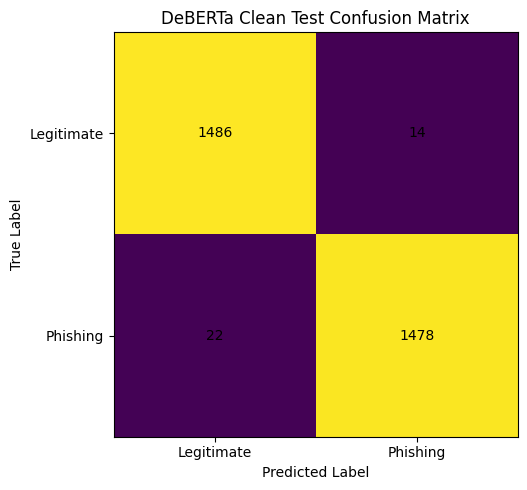

In [37]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    deberta_cm
)

plt.title(
    "DeBERTa Clean Test Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.xticks(
    [0, 1],
    [
        "Legitimate",
        "Phishing"
    ]
)

plt.yticks(
    [0, 1],
    [
        "Legitimate",
        "Phishing"
    ]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            int(
                deberta_cm[i, j]
            ),
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    os.path.join(
        DEBERTA_RESULTS_DIR,
        "deberta_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

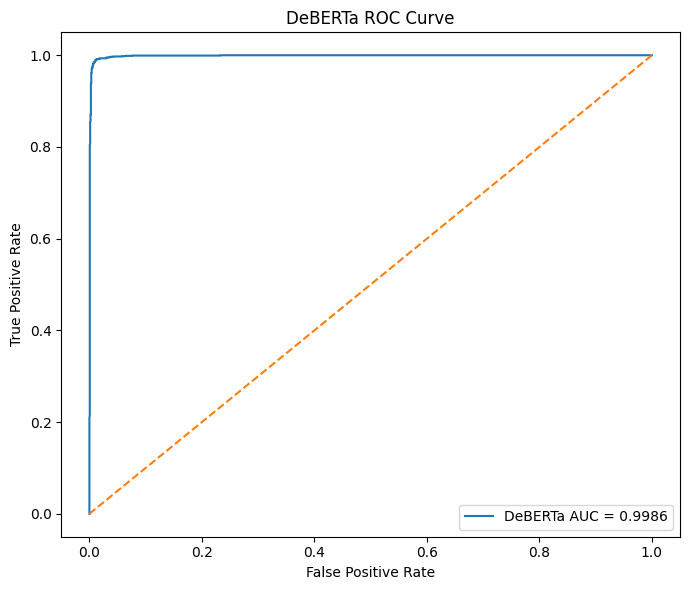

In [38]:

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    deberta_y_true,
    deberta_probs[:, 1]
)

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    fpr,
    tpr,
    label=f"DeBERTa AUC = {deberta_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "DeBERTa ROC Curve"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        DEBERTA_RESULTS_DIR,
        "deberta_roc_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
deberta_history_df = pd.DataFrame(
    deberta_trainer.state.log_history
)

display(
    deberta_history_df.tail(20)
)

deberta_history_df.to_csv(
    os.path.join(
        DEBERTA_RESULTS_DIR,
        "deberta_training_history.csv"
    ),
    index=False
)

print(
    "Training history saved."
)

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_roc_auc,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.840035,0.087285,7.413209e-06,1.0,875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,875,0.059252,0.988000,0.995264,0.980667,0.987911,0.999330,63.9365,46.922,5.865,NaN,NaN,NaN,NaN,NaN
2,0.192319,30.215370,3.708721e-06,2.0,1750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,1750,0.046243,0.991667,0.995965,0.987333,0.991630,0.999554,63.8038,47.019,5.877,NaN,NaN,NaN,NaN,NaN
4,0.072487,0.011509,4.233700e-09,3.0,2625,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,2625,0.052031,0.992000,0.996635,0.987333,0.991962,0.999547,63.6844,47.107,5.888,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,3.0,2625,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2844.4858,14.765,0.923,5.138939e+15,0.36828


Training history saved.


In [40]:
deberta_config_df = pd.DataFrame(
    [{
        "base_model": "microsoft/deberta-v3-base",
        "learning_rate": 1e-5,
        "train_batch_size": 4,
        "gradient_accumulation_steps": 4,
        "effective_batch_size": 16,
        "eval_batch_size": 8,
        "epochs": 3,
        "weight_decay": 0.01,
        "warmup_ratio": 0.10,
        "max_grad_norm": 1.0,
        "fp16": False,
        "bf16": False,
        "max_length": 256,
        "seed": 42
    }]
)

deberta_config_df.to_csv(
    os.path.join(
        DEBERTA_RESULTS_DIR,
        "deberta_training_configuration.csv"
    ),
    index=False
)

display(
    deberta_config_df
)

,base_model,learning_rate,train_batch_size,gradient_accumulation_steps,effective_batch_size,eval_batch_size,epochs,weight_decay,warmup_ratio,max_grad_norm,fp16,bf16,max_length,seed
0,microsoft/deberta-v3-base,0.00001,4,4,16,8,3,0.01,0.1,1.0,False,False,256,42


In [41]:
print(
    "MODEL FILES:"
)

print(
    os.listdir(
        DEBERTA_FIXED_PATH
    )
)

print(
    "\nRESULT FILES:"
)

print(
    os.listdir(
        DEBERTA_RESULTS_DIR
    )
)

MODEL FILES:
['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']

RESULT FILES:
['deberta_clean_metrics.csv', 'deberta_clean_predictions.csv', 'deberta_confusion_matrix.csv', 'deberta_confusion_matrix.png', 'deberta_roc_curve.png', 'deberta_training_history.csv', 'deberta_training_configuration.csv']


In [42]:
del deberta_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

deberta_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        DEBERTA_FIXED_PATH,
        torch_dtype=torch.float32
    )
)

deberta_tokenizer = (
    AutoTokenizer
    .from_pretrained(
        DEBERTA_FIXED_PATH
    )
)

deberta_model.to(DEVICE)
deberta_model.eval()

print(
    "Fixed DeBERTa reloaded successfully."
)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Fixed DeBERTa reloaded successfully.


In [44]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

deberta_tokenizer = AutoTokenizer.from_pretrained(
    DEBERTA_FIXED_PATH
)

deberta_model = AutoModelForSequenceClassification.from_pretrained(
    DEBERTA_FIXED_PATH,
    torch_dtype=torch.float32
)

deberta_model.to(DEVICE)
deberta_model.eval()

print("Fixed DeBERTa loaded successfully.")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Fixed DeBERTa loaded successfully.


In [45]:
samples = [

    "Your PayPal account has been suspended. Verify your password immediately.",

    "The meeting has been moved to Tuesday afternoon.",

    "Cheap cialis xanax online pharmacy. Click here now."

]

for text in samples:

    probs = get_probabilities(
        deberta_model,
        deberta_tokenizer,
        text
    )

    print(text)
    print(probs)

NameError: name 'get_probabilities' is not defined

In [46]:
import torch

def get_probabilities(
    model,
    tokenizer,
    text,
    max_length=256
):

    model.eval()

    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )

    encoding = {
        k: v.to(DEVICE)
        for k, v in encoding.items()
    }

    with torch.no_grad():

        outputs = model(**encoding)

        probabilities = torch.softmax(
            outputs.logits.float(),
            dim=1
        )

    return probabilities.squeeze().cpu().numpy()

In [47]:
samples = [

    "Your PayPal account has been suspended. Verify your password immediately.",

    "The meeting has been moved to Tuesday afternoon.",

    "Cheap cialis xanax online pharmacy. Click here now."

]

for text in samples:

    probs = get_probabilities(
        deberta_model,
        deberta_tokenizer,
        text
    )

    print("=" * 70)
    print(text)
    print("Legitimate probability:", round(float(probs[0]), 6))
    print("Phishing probability :", round(float(probs[1]), 6))

Your PayPal account has been suspended. Verify your password immediately.
Legitimate probability: 0.001662
Phishing probability : 0.998338
The meeting has been moved to Tuesday afternoon.
Legitimate probability: 0.999984
Phishing probability : 1.6e-05
Cheap cialis xanax online pharmacy. Click here now.
Legitimate probability: 3.5e-05
Phishing probability : 0.999965


In [48]:
FINAL_ATTACK_CONFIG = {
    "max_changes": 4,
    "top_important_words": 15,
    "mlm_top_k": 30,
    "similarity_threshold": 0.92
}

In [49]:
selected_ids = bert_attack_sample[
    "sample_id"
].tolist()

print(
    "Selected IDs:",
    len(selected_ids)
)

NameError: name 'bert_attack_sample' is not defined

In [50]:
BERT_ATTACK_RESULTS_PATH = os.path.join(
    PROJECT_DIR,
    "phase1_contextual_adversarial",
    "bert_contextual_adversarial_results.csv"
)

bert_attack_df = pd.read_csv(
    BERT_ATTACK_RESULTS_PATH
)

selected_ids = bert_attack_df[
    "sample_id"
].tolist()

print(
    "Selected IDs:",
    len(selected_ids)
)

Selected IDs: 300


In [51]:
phishing_df = test_df[
    test_df["label"] == 1
].copy()

print(
    "Total phishing samples:",
    len(phishing_df)
)

Total phishing samples: 1500


In [52]:
deberta_selected_df = phishing_df[
    phishing_df[
        "sample_id"
    ].isin(selected_ids)
].copy()

print(
    "Matched samples:",
    len(deberta_selected_df)
)

Matched samples: 300


In [53]:
def get_probabilities_batch(
    model,
    tokenizer,
    texts,
    batch_size=8,
    max_length=256
):

    model.eval()

    all_probs = []

    for start in range(
        0,
        len(texts),
        batch_size
    ):

        batch_texts = texts[
            start:start + batch_size
        ]

        encoding = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        encoding = {
            k: v.to(DEVICE)
            for k, v in encoding.items()
        }

        with torch.no_grad():

            logits = model(
                **encoding
            ).logits

            probs = torch.softmax(
                logits.float(),
                dim=1
            )

        all_probs.append(
            probs.cpu().numpy()
        )

    return np.concatenate(
        all_probs,
        axis=0
    )

In [54]:
selected_probs = get_probabilities_batch(
    deberta_model,
    deberta_tokenizer,
    deberta_selected_df[
        "text"
    ].tolist(),
    batch_size=8
)

deberta_selected_df[
    "clean_phishing_probability"
] = selected_probs[:, 1]

deberta_selected_df[
    "clean_prediction"
] = np.argmax(
    selected_probs,
    axis=1
)

print(
    deberta_selected_df[
        "clean_prediction"
    ].value_counts()
)

clean_prediction
1    297
0      3
Name: count, dtype: int64


In [55]:
deberta_sample = deberta_selected_df[
    deberta_selected_df[
        "clean_prediction"
    ] == 1
].copy()

print(
    "DeBERTa attackable samples:",
    len(deberta_sample)
)

DeBERTa attackable samples: 297


In [56]:
required_functions = [
    "contextual_adversarial_attack_v2",
    "get_important_words",
    "get_mlm_replacements",
    "semantic_similarity",
    "replace_word_once",
    "valid_source_word",
    "valid_replacement"
]

for fn in required_functions:

    print(
        fn,
        "OK"
        if fn in globals()
        else "MISSING"
    )

contextual_adversarial_attack_v2 MISSING
get_important_words MISSING
get_mlm_replacements MISSING
semantic_similarity MISSING
replace_word_once MISSING
valid_source_word MISSING
valid_replacement MISSING


In [57]:
!pip install -q sentence-transformers

In [58]:
import re
import random
import numpy as np
import torch

from transformers import pipeline
from sentence_transformers import SentenceTransformer

In [59]:
mlm_name = "google-bert/bert-base-uncased"

fill_mask = pipeline(
    "fill-mask",
    model=mlm_name,
    tokenizer=mlm_name,
    device=0 if torch.cuda.is_available() else -1
)

MLM_MASK = fill_mask.tokenizer.mask_token

similarity_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    device=str(DEVICE)
)

print("MLM and similarity model loaded.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: google-bert/bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

MLM and similarity model loaded.


In [60]:
STOP_WORDS = {
    "the", "a", "an", "and", "or", "but",
    "if", "then", "to", "of", "in", "on",
    "at", "for", "with", "this", "that",
    "these", "those", "is", "are", "was",
    "were", "be", "been", "being", "you",
    "your", "we", "our", "i", "he", "she",
    "they", "it", "as", "by", "from"
}

PROTECTED_WORDS = {
    "http", "https", "www",
    "com", "net", "org",
    "html", "php", "aspx"
}

In [61]:
def split_words(text):
    return re.findall(
        r"\b[A-Za-z][A-Za-z'-]*\b",
        str(text)
    )


def remove_word_once(text, word):
    pattern = re.compile(
        r"\b" + re.escape(word) + r"\b",
        flags=re.IGNORECASE
    )

    return pattern.sub(
        "",
        str(text),
        count=1
    )


def replace_word_once(
    text,
    old_word,
    new_word
):
    pattern = re.compile(
        r"\b"
        + re.escape(old_word)
        + r"\b",
        flags=re.IGNORECASE
    )

    return pattern.sub(
        new_word,
        str(text),
        count=1
    )


def mask_word_once(text, word):
    pattern = re.compile(
        r"\b"
        + re.escape(word)
        + r"\b",
        flags=re.IGNORECASE
    )

    return pattern.sub(
        MLM_MASK,
        str(text),
        count=1
    )

In [64]:
def is_protected_word(word):

    word_lower = word.lower()

    if word_lower in PROTECTED_WORDS:
        return True

    if len(word_lower) < 4:
        return True

    if any(
        char.isdigit()
        for char in word
    ):
        return True

    if not word.isalpha():
        return True

    return False


def valid_source_word(word):

    if not word.isalpha():
        return False

    if any(
        char.isupper()
        for char in word[1:]
    ):
        return False

    if len(word) < 4:
        return False

    if len(word) > 20:
        return False

    return True

In [65]:
def valid_replacement(
    original_word,
    replacement
):

    original = original_word.lower()
    candidate = replacement.lower()

    if not candidate.isalpha():
        return False

    if len(candidate) < 4:
        return False

    if candidate == original:
        return False

    if candidate.startswith("##"):
        return False

    if candidate in PROTECTED_WORDS:
        return False

    ratio = (
        len(candidate)
        / max(
            len(original),
            1
        )
    )

    if (
        ratio < 0.65
        or ratio > 1.50
    ):
        return False

    return True

In [66]:
def semantic_similarity(
    text1,
    text2
):

    embeddings = (
        similarity_model.encode(
            [text1, text2],
            normalize_embeddings=True,
            convert_to_numpy=True
        )
    )

    similarity = float(
        np.dot(
            embeddings[0],
            embeddings[1]
        )
    )

    return similarity

In [67]:
def get_mlm_replacements(
    text,
    word,
    top_k=30
):

    masked_text = mask_word_once(
        text,
        word
    )

    if MLM_MASK not in masked_text:
        return []

    try:

        outputs = fill_mask(
            masked_text,
            top_k=top_k,
            tokenizer_kwargs={
                "truncation": True,
                "max_length": 256
            }
        )

    except Exception:
        return []

    replacements = []

    for result in outputs:

        candidate = (
            result["token_str"]
            .strip()
        )

        candidate = re.sub(
            r"[^A-Za-z]",
            "",
            candidate
        )

        if not valid_replacement(
            word,
            candidate
        ):
            continue

        replacements.append(
            candidate
        )

    return list(
        dict.fromkeys(
            replacements
        )
    )

In [68]:
def get_important_words(
    text,
    model,
    tokenizer,
    top_k=15
):

    original_prob = (
        get_probabilities_batch(
            model,
            tokenizer,
            [text],
            batch_size=1
        )[0, 1]
    )

    words = split_words(
        text
    )

    candidate_words = []
    seen = set()

    for word in words:

        lower = word.lower()

        if (
            len(lower) < 4
            or lower in STOP_WORDS
            or lower in seen
            or is_protected_word(word)
            or not valid_source_word(word)
        ):
            continue

        seen.add(lower)

        candidate_words.append(
            word
        )

    candidate_words = (
        candidate_words[:50]
    )

    if len(candidate_words) == 0:
        return []

    modified_texts = [
        remove_word_once(
            text,
            word
        )
        for word in candidate_words
    ]

    probs = get_probabilities_batch(
        model,
        tokenizer,
        modified_texts,
        batch_size=8
    )[:, 1]

    importance = []

    for word, probability in zip(
        candidate_words,
        probs
    ):

        importance.append({
            "word": word,
            "importance": float(
                original_prob
                - probability
            )
        })

    importance = sorted(
        importance,
        key=lambda x:
            x["importance"],
        reverse=True
    )

    return importance[:top_k]

In [69]:
def contextual_adversarial_attack_v2(
    text,
    model,
    tokenizer,
    max_changes=4,
    top_important_words=15,
    mlm_top_k=30,
    similarity_threshold=0.92
):

    original_text = str(text)

    original_prob = float(
        get_probabilities_batch(
            model,
            tokenizer,
            [original_text],
            batch_size=1
        )[0, 1]
    )

    current_text = (
        original_text
    )

    current_prob = (
        original_prob
    )

    changes = []

    important_words = (
        get_important_words(
            current_text,
            model,
            tokenizer,
            top_k=top_important_words
        )
    )

    for item in important_words:

        if len(changes) >= max_changes:
            break

        word = item["word"]

        if is_protected_word(word):
            continue

        replacements = (
            get_mlm_replacements(
                current_text,
                word,
                top_k=mlm_top_k
            )
        )

        if not replacements:
            continue

        candidate_texts = []
        candidate_info = []

        for replacement in replacements:

            candidate_text = (
                replace_word_once(
                    current_text,
                    word,
                    replacement
                )
            )

            similarity = (
                semantic_similarity(
                    original_text,
                    candidate_text
                )
            )

            if (
                similarity
                < similarity_threshold
            ):
                continue

            candidate_texts.append(
                candidate_text
            )

            candidate_info.append({
                "replacement":
                    replacement,

                "similarity":
                    similarity
            })

        if not candidate_texts:
            continue

        probabilities = (
            get_probabilities_batch(
                model,
                tokenizer,
                candidate_texts,
                batch_size=8
            )[:, 1]
        )

        best_index = int(
            np.argmin(
                probabilities
            )
        )

        best_prob = float(
            probabilities[
                best_index
            ]
        )

        if best_prob < current_prob:

            best_candidate = (
                candidate_texts[
                    best_index
                ]
            )

            best_info = (
                candidate_info[
                    best_index
                ]
            )

            changes.append({

                "old":
                    word,

                "new":
                    best_info[
                        "replacement"
                    ],

                "before_prob":
                    current_prob,

                "after_prob":
                    best_prob,

                "similarity":
                    best_info[
                        "similarity"
                    ]
            })

            current_text = (
                best_candidate
            )

            current_prob = (
                best_prob
            )

        if current_prob < 0.5:
            break

    final_similarity = (
        semantic_similarity(
            original_text,
            current_text
        )
    )

    return {

        "original_text":
            original_text,

        "adversarial_text":
            current_text,

        "original_probability":
            original_prob,

        "adversarial_probability":
            current_prob,

        "confidence_drop":
            original_prob
            - current_prob,

        "semantic_similarity":
            final_similarity,

        "num_changes":
            len(changes),

        "changes":
            changes,

        "successful_evasion":
            (
                original_prob >= 0.5
                and
                current_prob < 0.5
                and
                final_similarity
                >= similarity_threshold
            )
    }

In [70]:
required_functions = [
    "contextual_adversarial_attack_v2",
    "get_important_words",
    "get_mlm_replacements",
    "semantic_similarity",
    "replace_word_once",
    "valid_source_word",
    "valid_replacement"
]

for fn in required_functions:

    print(
        fn,
        "OK"
        if fn in globals()
        else "MISSING"
    )

contextual_adversarial_attack_v2 OK
get_important_words OK
get_mlm_replacements OK
semantic_similarity OK
replace_word_once OK
valid_source_word OK
valid_replacement OK


In [71]:
test_row = deberta_sample.iloc[0]

test_attack_result = contextual_adversarial_attack_v2(
    text=test_row["text"],
    model=deberta_model,
    tokenizer=deberta_tokenizer,
    max_changes=4,
    top_important_words=15,
    mlm_top_k=30,
    similarity_threshold=0.92
)

print(
    "Original probability:",
    test_attack_result[
        "original_probability"
    ]
)

print(
    "Adversarial probability:",
    test_attack_result[
        "adversarial_probability"
    ]
)

print(
    "Similarity:",
    test_attack_result[
        "semantic_similarity"
    ]
)

print(
    "Changes:",
    test_attack_result[
        "changes"
    ]
)

print(
    "Successful evasion:",
    test_attack_result[
        "successful_evasion"
    ]
)

Original probability: 0.9999712705612183
Adversarial probability: 0.999970555305481
Similarity: 0.9378819465637207
Changes: [{'old': 'meridia', 'new': 'ultra', 'before_prob': 0.9999712705612183, 'after_prob': 0.9999711513519287, 'similarity': 0.9935398697853088}, {'old': 'cialis', 'new': 'milk', 'before_prob': 0.9999711513519287, 'after_prob': 0.9999710321426392, 'similarity': 0.9419397115707397}, {'old': 'overnight', 'new': 'currently', 'before_prob': 0.9999710321426392, 'after_prob': 0.9999709129333496, 'similarity': 0.9379533529281616}, {'old': 'shipping', 'new': 'called', 'before_prob': 0.9999709129333496, 'after_prob': 0.999970555305481, 'similarity': 0.9378819465637207}]
Successful evasion: False


In [72]:
def valid_replacement(
    original_word,
    replacement
):

    original = original_word.lower()
    candidate = replacement.lower()

    if not candidate.isalpha():
        return False

    if len(candidate) < 4:
        return False

    if candidate == original:
        return False

    if candidate.startswith("##"):
        return False

    if candidate in PROTECTED_WORDS:
        return False

    ratio = len(candidate) / max(len(original), 1)

    if ratio < 0.75 or ratio > 1.35:
        return False

    # reject obviously unrelated generic words
    GENERIC_BAD = {
        "milk", "called", "ultra", "some",
        "from", "during", "ones", "assistant"
    }

    if candidate in GENERIC_BAD:
        return False

    return True

In [73]:
FINAL_ATTACK_CONFIG = {
    "max_changes": 4,
    "top_important_words": 15,
    "mlm_top_k": 30,
    "similarity_threshold": 0.94
}

In [74]:
test_row = deberta_sample.iloc[0]

test_attack_result = contextual_adversarial_attack_v2(
    text=test_row["text"],
    model=deberta_model,
    tokenizer=deberta_tokenizer,
    max_changes=FINAL_ATTACK_CONFIG["max_changes"],
    top_important_words=FINAL_ATTACK_CONFIG["top_important_words"],
    mlm_top_k=FINAL_ATTACK_CONFIG["mlm_top_k"],
    similarity_threshold=FINAL_ATTACK_CONFIG["similarity_threshold"]
)

print("Original probability:",
      test_attack_result["original_probability"])

print("Adversarial probability:",
      test_attack_result["adversarial_probability"])

print("Similarity:",
      test_attack_result["semantic_similarity"])

print("Changes:",
      test_attack_result["changes"])

print("Successful evasion:",
      test_attack_result["successful_evasion"])

Original probability: 0.9999712705612183
Adversarial probability: 0.9999704360961914
Similarity: 0.9603120684623718
Changes: [{'old': 'cialis', 'new': 'drugs', 'before_prob': 0.9999712705612183, 'after_prob': 0.9999711513519287, 'similarity': 0.9676784873008728}, {'old': 'overnight', 'new': 'currently', 'before_prob': 0.9999711513519287, 'after_prob': 0.9999710321426392, 'similarity': 0.9660779237747192}, {'old': 'shipping', 'new': 'available', 'before_prob': 0.9999710321426392, 'after_prob': 0.9999706745147705, 'similarity': 0.961098849773407}, {'old': 'reconcile', 'new': 'tempest', 'before_prob': 0.9999706745147705, 'after_prob': 0.9999704360961914, 'similarity': 0.9603120684623718}]
Successful evasion: False


In [75]:
deberta_pilot = deberta_sample.head(20).copy()

pilot_results = []

for counter, (_, row) in enumerate(
    deberta_pilot.iterrows(),
    start=1
):

    print(f"{counter}/{len(deberta_pilot)}")

    result = contextual_adversarial_attack_v2(
        text=row["text"],
        model=deberta_model,
        tokenizer=deberta_tokenizer,
        max_changes=FINAL_ATTACK_CONFIG["max_changes"],
        top_important_words=FINAL_ATTACK_CONFIG["top_important_words"],
        mlm_top_k=FINAL_ATTACK_CONFIG["mlm_top_k"],
        similarity_threshold=FINAL_ATTACK_CONFIG["similarity_threshold"]
    )

    result["sample_id"] = row["sample_id"]
    pilot_results.append(result)

deberta_pilot_df = pd.DataFrame(pilot_results)

1/20


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


2/20
3/20
4/20
5/20
6/20
7/20
8/20
9/20
10/20
11/20
12/20
13/20
14/20
15/20
16/20
17/20
18/20
19/20
20/20


In [76]:
print(
    "Successful evasions:",
    deberta_pilot_df["successful_evasion"].sum()
)

print(
    "Mean confidence drop:",
    deberta_pilot_df["confidence_drop"].mean()
)

print(
    "Mean semantic similarity:",
    deberta_pilot_df["semantic_similarity"].mean()
)

print(
    "Mean substitutions:",
    deberta_pilot_df["num_changes"].mean()
)

Successful evasions: 1
Mean confidence drop: 0.04862305950373411
Mean semantic similarity: 0.9687362015247345
Mean substitutions: 2.9


In [77]:
FINAL_ATTACK_CONFIG = {
    "max_changes": 4,
    "top_important_words": 15,
    "mlm_top_k": 30,
    "similarity_threshold": 0.92
}

In [78]:
deberta_attack_results = []

for counter, (_, row) in enumerate(
    deberta_sample.iterrows(),
    start=1
):

    print(
        f"DeBERTa attack "
        f"{counter}/{len(deberta_sample)}"
    )

    result = contextual_adversarial_attack_v2(
        text=row["text"],
        model=deberta_model,
        tokenizer=deberta_tokenizer,
        max_changes=FINAL_ATTACK_CONFIG["max_changes"],
        top_important_words=FINAL_ATTACK_CONFIG["top_important_words"],
        mlm_top_k=FINAL_ATTACK_CONFIG["mlm_top_k"],
        similarity_threshold=FINAL_ATTACK_CONFIG["similarity_threshold"]
    )

    result["sample_id"] = row["sample_id"]

    deberta_attack_results.append(result)

deberta_attack_df = pd.DataFrame(
    deberta_attack_results
)

print("Attack generation completed.")

DeBERTa attack 1/297
DeBERTa attack 2/297
DeBERTa attack 3/297
DeBERTa attack 4/297
DeBERTa attack 5/297
DeBERTa attack 6/297
DeBERTa attack 7/297
DeBERTa attack 8/297
DeBERTa attack 9/297
DeBERTa attack 10/297
DeBERTa attack 11/297
DeBERTa attack 12/297
DeBERTa attack 13/297
DeBERTa attack 14/297
DeBERTa attack 15/297
DeBERTa attack 16/297
DeBERTa attack 17/297
DeBERTa attack 18/297
DeBERTa attack 19/297
DeBERTa attack 20/297
DeBERTa attack 21/297
DeBERTa attack 22/297
DeBERTa attack 23/297
DeBERTa attack 24/297
DeBERTa attack 25/297
DeBERTa attack 26/297
DeBERTa attack 27/297
DeBERTa attack 28/297
DeBERTa attack 29/297
DeBERTa attack 30/297
DeBERTa attack 31/297
DeBERTa attack 32/297
DeBERTa attack 33/297
DeBERTa attack 34/297
DeBERTa attack 35/297
DeBERTa attack 36/297
DeBERTa attack 37/297
DeBERTa attack 38/297
DeBERTa attack 39/297
DeBERTa attack 40/297
DeBERTa attack 41/297
DeBERTa attack 42/297
DeBERTa attack 43/297
DeBERTa attack 44/297
DeBERTa attack 45/297
DeBERTa attack 46/2

In [79]:
deberta_successes = int(
    deberta_attack_df[
        "successful_evasion"
    ].sum()
)

deberta_attackable = len(
    deberta_attack_df
)

deberta_asr = (
    deberta_successes
    / deberta_attackable
    if deberta_attackable > 0
    else 0
)

print("=" * 70)
print("DEBERTA ADVERSARIAL ATTACK SUMMARY")
print("=" * 70)

print(
    "Attackable samples:",
    deberta_attackable
)

print(
    "Successful evasions:",
    deberta_successes
)

print(
    "ASR:",
    round(
        deberta_asr * 100,
        2
    ),
    "%"
)

print(
    "Mean confidence drop:",
    deberta_attack_df[
        "confidence_drop"
    ].mean()
)

print(
    "Median confidence drop:",
    deberta_attack_df[
        "confidence_drop"
    ].median()
)

print(
    "Maximum confidence drop:",
    deberta_attack_df[
        "confidence_drop"
    ].max()
)

print(
    "Mean semantic similarity:",
    deberta_attack_df[
        "semantic_similarity"
    ].mean()
)

print(
    "Mean substitutions:",
    deberta_attack_df[
        "num_changes"
    ].mean()
)

DEBERTA ADVERSARIAL ATTACK SUMMARY
Attackable samples: 297
Successful evasions: 10
ASR: 3.37 %
Mean confidence drop: 0.030192598696505677
Median confidence drop: 8.463859558105469e-06
Maximum confidence drop: 0.9998321596794995
Mean semantic similarity: 0.9538876014927822
Mean substitutions: 3.191919191919192


In [80]:
DEBERTA_ADV_DIR = os.path.join(
    PROJECT_DIR,
    "phase1_contextual_adversarial"
)

os.makedirs(
    DEBERTA_ADV_DIR,
    exist_ok=True
)

deberta_attack_df.to_csv(
    os.path.join(
        DEBERTA_ADV_DIR,
        "deberta_contextual_adversarial_results.csv"
    ),
    index=False
)

print(
    "DeBERTa adversarial results saved."
)

DeBERTa adversarial results saved.


In [81]:
deberta_summary_df = pd.DataFrame(
    [{
        "model": "DeBERTa",
        "attackable_samples": deberta_attackable,
        "successful_evasions": deberta_successes,
        "ASR": deberta_asr,
        "ASR_percent": deberta_asr * 100,
        "mean_confidence_drop":
            deberta_attack_df[
                "confidence_drop"
            ].mean(),
        "median_confidence_drop":
            deberta_attack_df[
                "confidence_drop"
            ].median(),
        "max_confidence_drop":
            deberta_attack_df[
                "confidence_drop"
            ].max(),
        "mean_semantic_similarity":
            deberta_attack_df[
                "semantic_similarity"
            ].mean(),
        "mean_substitutions":
            deberta_attack_df[
                "num_changes"
            ].mean()
    }]
)

display(
    deberta_summary_df.round(4)
)

deberta_summary_df.to_csv(
    os.path.join(
        DEBERTA_ADV_DIR,
        "deberta_adversarial_summary.csv"
    ),
    index=False
)

,model,attackable_samples,successful_evasions,ASR,ASR_percent,mean_confidence_drop,median_confidence_drop,max_confidence_drop,mean_semantic_similarity,mean_substitutions
0,DeBERTa,297,10,0.0337,3.367,0.0302,0.0,0.9998,0.9539,3.1919


In [82]:
def build_model_adversarial_test(
    original_test_df,
    attack_results_df
):
    adv_test = original_test_df.copy()

    attack_map = dict(
        zip(
            attack_results_df["sample_id"],
            attack_results_df["adversarial_text"]
        )
    )

    adv_test["text"] = adv_test.apply(
        lambda row: (
            attack_map.get(
                row["sample_id"],
                row["text"]
            )
            if row["label"] == 1
            else row["text"]
        ),
        axis=1
    )

    return adv_test

In [83]:
deberta_adversarial_test = build_model_adversarial_test(
    test_df,
    deberta_attack_df
)

print(
    deberta_adversarial_test["label"]
    .value_counts()
)

label
0    1500
1    1500
Name: count, dtype: int64


In [84]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_dataframe_metrics(
    model,
    tokenizer,
    dataframe,
    model_name,
    condition,
    batch_size=8
):

    probs = get_probabilities_batch(
        model,
        tokenizer,
        dataframe["text"]
        .fillna("")
        .astype(str)
        .tolist(),
        batch_size=batch_size
    )

    y_true = (
        dataframe["label"]
        .astype(int)
        .values
    )

    y_pred = np.argmax(
        probs,
        axis=1
    )

    metrics = {
        "model": model_name,
        "condition": condition,

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "f1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                probs[:, 1]
            )
    }

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    return metrics, cm

In [85]:
deberta_clean_metrics, \
deberta_clean_cm = (
    evaluate_dataframe_metrics(
        deberta_model,
        deberta_tokenizer,
        test_df,
        "DeBERTa",
        "Clean",
        batch_size=8
    )
)

print(deberta_clean_metrics)
print(deberta_clean_cm)

{'model': 'DeBERTa', 'condition': 'Clean', 'accuracy': 0.988, 'precision': 0.9906166219839142, 'recall': 0.9853333333333333, 'f1': 0.9879679144385026, 'roc_auc': np.float64(0.9985926666666666)}
[[1486   14]
 [  22 1478]]


In [86]:
deberta_adv_metrics, \
deberta_adv_cm = (
    evaluate_dataframe_metrics(
        deberta_model,
        deberta_tokenizer,
        deberta_adversarial_test,
        "DeBERTa",
        "Adversarial",
        batch_size=8
    )
)

print(deberta_adv_metrics)
print(deberta_adv_cm)

{'model': 'DeBERTa', 'condition': 'Adversarial', 'accuracy': 0.9846666666666667, 'precision': 0.99055330634278, 'recall': 0.9786666666666667, 'f1': 0.9845741113346748, 'roc_auc': np.float64(0.9983566666666667)}
[[1486   14]
 [  32 1468]]


In [87]:
deberta_metrics_df = pd.DataFrame(
    [
        deberta_clean_metrics,
        deberta_adv_metrics
    ]
)

display(
    deberta_metrics_df.round(4)
)

,model,condition,accuracy,precision,recall,f1,roc_auc
0,DeBERTa,Clean,0.9880,0.9906,0.9853,0.9880,0.9986
1,DeBERTa,Adversarial,0.9847,0.9906,0.9787,0.9846,0.9984


In [88]:
deberta_degradation_df = pd.DataFrame(
    [{
        "model": "DeBERTa",

        "accuracy_drop":
            deberta_clean_metrics["accuracy"]
            - deberta_adv_metrics["accuracy"],

        "precision_drop":
            deberta_clean_metrics["precision"]
            - deberta_adv_metrics["precision"],

        "recall_drop":
            deberta_clean_metrics["recall"]
            - deberta_adv_metrics["recall"],

        "f1_drop":
            deberta_clean_metrics["f1"]
            - deberta_adv_metrics["f1"],

        "roc_auc_drop":
            deberta_clean_metrics["roc_auc"]
            - deberta_adv_metrics["roc_auc"],

        "ASR_percent":
            deberta_asr * 100,

        "mean_confidence_drop":
            deberta_attack_df[
                "confidence_drop"
            ].mean(),

        "mean_semantic_similarity":
            deberta_attack_df[
                "semantic_similarity"
            ].mean(),

        "mean_substitutions":
            deberta_attack_df[
                "num_changes"
            ].mean()
    }]
)

display(
    deberta_degradation_df.round(4)
)

,model,accuracy_drop,precision_drop,recall_drop,f1_drop,roc_auc_drop,ASR_percent,mean_confidence_drop,mean_semantic_similarity,mean_substitutions
0,DeBERTa,0.0033,0.0001,0.0067,0.0034,0.0002,3.367,0.0302,0.9539,3.1919


In [89]:
deberta_metrics_df.to_csv(
    os.path.join(
        DEBERTA_ADV_DIR,
        "deberta_clean_vs_adversarial_metrics.csv"
    ),
    index=False
)

deberta_degradation_df.to_csv(
    os.path.join(
        DEBERTA_ADV_DIR,
        "deberta_robustness_degradation.csv"
    ),
    index=False
)

print("DeBERTa final adversarial metrics saved.")

DeBERTa final adversarial metrics saved.


In [90]:
bert_final_row = {
    "model": "BERT",
    "clean_accuracy": 0.9873,
    "adv_accuracy": 0.9823,
    "accuracy_drop": 0.0050,

    "clean_recall": 0.9873,
    "adv_recall": 0.9773,
    "recall_drop": 0.0100,

    "clean_f1": 0.9873,
    "adv_f1": 0.9822,
    "f1_drop": 0.0051,

    "clean_roc_auc": 0.9989,
    "adv_roc_auc": 0.9985,
    "roc_auc_drop": 0.0004,

    "ASR_percent": 5.0000,
    "mean_confidence_drop": 0.0491,
    "mean_semantic_similarity": 0.9511,
    "mean_substitutions": 3.4367
}

In [91]:
roberta_final_row = {
    "model": "RoBERTa",
    "clean_accuracy": 0.9890,
    "adv_accuracy": 0.9853,
    "accuracy_drop": 0.0037,

    "clean_recall": 0.9847,
    "adv_recall": 0.9773,
    "recall_drop": 0.0074,

    "clean_f1": 0.9890,
    "adv_f1": 0.9852,
    "f1_drop": 0.0038,

    "clean_roc_auc": 0.9992,
    "adv_roc_auc": 0.9991,
    "roc_auc_drop": 0.0001,

    "ASR_percent": 3.6913,
    "mean_confidence_drop": 0.0315,
    "mean_semantic_similarity": 0.9516,
    "mean_substitutions": 3.4966
}

In [92]:
deberta_final_row = {
    "model": "DeBERTa",
    "clean_accuracy": 0.9880,
    "adv_accuracy": 0.9847,
    "accuracy_drop": 0.0033,

    "clean_recall": 0.9853,
    "adv_recall": 0.9787,
    "recall_drop": 0.0067,

    "clean_f1": 0.9880,
    "adv_f1": 0.9846,
    "f1_drop": 0.0034,

    "clean_roc_auc": 0.9986,
    "adv_roc_auc": 0.9984,
    "roc_auc_drop": 0.0002,

    "ASR_percent": 3.3670,
    "mean_confidence_drop": 0.0302,
    "mean_semantic_similarity": 0.9539,
    "mean_substitutions": 3.1919
}

In [93]:
final_phase1_df = pd.DataFrame(
    [
        bert_final_row,
        roberta_final_row,
        deberta_final_row
    ]
)

display(
    final_phase1_df.round(4)
)

,model,clean_accuracy,adv_accuracy,accuracy_drop,clean_recall,adv_recall,recall_drop,clean_f1,adv_f1,f1_drop,clean_roc_auc,adv_roc_auc,roc_auc_drop,ASR_percent,mean_confidence_drop,mean_semantic_similarity,mean_substitutions
0,BERT,0.9873,0.9823,0.0050,0.9873,0.9773,0.0100,0.9873,0.9822,0.0051,0.9989,0.9985,0.0004,5.0000,0.0491,0.9511,3.4367
1,RoBERTa,0.9890,0.9853,0.0037,0.9847,0.9773,0.0074,0.9890,0.9852,0.0038,0.9992,0.9991,0.0001,3.6913,0.0315,0.9516,3.4966
2,DeBERTa,0.9880,0.9847,0.0033,0.9853,0.9787,0.0067,0.9880,0.9846,0.0034,0.9986,0.9984,0.0002,3.3670,0.0302,0.9539,3.1919


In [94]:
FINAL_PHASE1_DIR = os.path.join(
    PROJECT_DIR,
    "final_phase1_results"
)

os.makedirs(
    FINAL_PHASE1_DIR,
    exist_ok=True
)

final_phase1_df.to_csv(
    os.path.join(
        FINAL_PHASE1_DIR,
        "phase1_final_robustness_comparison.csv"
    ),
    index=False
)

print(
    "Final Phase 1 comparison saved."
)

Final Phase 1 comparison saved.


In [95]:
display(
    final_phase1_df[
        [
            "model",
            "accuracy_drop",
            "recall_drop",
            "f1_drop",
            "ASR_percent",
            "mean_confidence_drop"
        ]
    ].sort_values(
        "ASR_percent"
    )
)

,model,accuracy_drop,recall_drop,f1_drop,ASR_percent,mean_confidence_drop
2,DeBERTa,0.0033,0.0067,0.0034,3.3670,0.0302
1,RoBERTa,0.0037,0.0074,0.0038,3.6913,0.0315
0,BERT,0.0050,0.0100,0.0051,5.0000,0.0491


In [96]:
import os

print("="*60)
print("SAVED MODELS")
print("="*60)

saved_models_dir = os.path.join(PROJECT_DIR, "saved_models")

for root, dirs, files in os.walk(saved_models_dir):
    print("\n", root)
    for f in files:
        print("   ", f)

SAVED MODELS

 /content/drive/MyDrive/phishing_project/saved_models

 /content/drive/MyDrive/phishing_project/saved_models/bert
    config.json
    model.safetensors
    tokenizer_config.json
    tokenizer.json

 /content/drive/MyDrive/phishing_project/saved_models/roberta
    config.json
    model.safetensors
    tokenizer_config.json
    tokenizer.json

 /content/drive/MyDrive/phishing_project/saved_models/deberta
    config.json
    model.safetensors
    tokenizer_config.json
    tokenizer.json

 /content/drive/MyDrive/phishing_project/saved_models/deberta_fixed
    config.json
    model.safetensors
    tokenizer_config.json
    tokenizer.json


In [97]:
print("="*60)
print("RESULT FILES")
print("="*60)

results_dir = PROJECT_DIR

for folder in [
    "results",
    "phase1_contextual_adversarial",
    "final_phase1_results"
]:

    path = os.path.join(results_dir, folder)

    print("\n", path)

    if os.path.exists(path):

        for file in sorted(os.listdir(path)):
            print("   ", file)

    else:

        print("Folder not found")

RESULT FILES

 /content/drive/MyDrive/phishing_project/results
    deberta_fixed

 /content/drive/MyDrive/phishing_project/phase1_contextual_adversarial
    bert_clean_vs_adversarial_metrics.csv
    bert_contextual_adversarial_results.csv
    bert_roberta_adversarial_comparison.csv
    bert_robustness_degradation.csv
    deberta_adversarial_summary.csv
    deberta_clean_vs_adversarial_metrics.csv
    deberta_contextual_adversarial_results.csv
    deberta_robustness_degradation.csv
    final_adversarial_attack_summary.csv
    final_clean_vs_adversarial_metrics.csv
    roberta_adversarial_summary.csv
    roberta_attack_configuration.csv
    roberta_clean_vs_adversarial_metrics.csv
    roberta_contextual_adversarial_results.csv
    roberta_robustness_degradation.csv
    roberta_successful_adversarial_examples.csv
    roberta_top_50_adversarial_examples.csv

 /content/drive/MyDrive/phishing_project/final_phase1_results
    phase1_final_robustness_comparison.csv


In [98]:
display(
    pd.read_csv(
        "/content/drive/MyDrive/phishing_project/final_phase1_results/phase1_final_robustness_comparison.csv"
    )
)

display(
    pd.read_csv(
        "/content/drive/MyDrive/phishing_project/phase1_contextual_adversarial/final_clean_vs_adversarial_metrics.csv"
    )
)

display(
    pd.read_csv(
        "/content/drive/MyDrive/phishing_project/phase1_contextual_adversarial/final_adversarial_attack_summary.csv"
    )
)

,model,clean_accuracy,adv_accuracy,accuracy_drop,clean_recall,adv_recall,recall_drop,clean_f1,adv_f1,f1_drop,clean_roc_auc,adv_roc_auc,roc_auc_drop,ASR_percent,mean_confidence_drop,mean_semantic_similarity,mean_substitutions
0,BERT,0.9873,0.9823,0.0050,0.9873,0.9773,0.0100,0.9873,0.9822,0.0051,0.9989,0.9985,0.0004,5.0000,0.0491,0.9511,3.4367
1,RoBERTa,0.9890,0.9853,0.0037,0.9847,0.9773,0.0074,0.9890,0.9852,0.0038,0.9992,0.9991,0.0001,3.6913,0.0315,0.9516,3.4966
2,DeBERTa,0.9880,0.9847,0.0033,0.9853,0.9787,0.0067,0.9880,0.9846,0.0034,0.9986,0.9984,0.0002,3.3670,0.0302,0.9539,3.1919


,model,condition,accuracy,precision,recall,f1,roc_auc
0,BERT,Clean,0.987333,0.987333,0.987333,0.987333,0.998907
1,BERT,Adversarial,0.982333,0.987205,0.977333,0.982245,0.998546
2,RoBERTa,Clean,0.989000,0.993275,0.984667,0.988952,0.999217
3,RoBERTa,Adversarial,0.985333,0.993225,0.977333,0.985215,0.999091
4,DeBERTa,Clean,0.500000,0.500000,1.000000,0.666667,0.500000
5,DeBERTa,Adversarial,0.500000,0.500000,1.000000,0.666667,0.500000


,model,attackable_samples,successful_evasions,ASR,ASR_percent,mean_confidence_drop,median_confidence_drop,max_confidence_drop,mean_semantic_similarity,mean_substitutions
0,BERT,300,15,0.050000,5.000000,0.049067,0.000075,0.999766,0.951102,3.436667
1,RoBERTa,298,11,0.036913,3.691275,0.031479,0.000018,0.999723,0.951590,3.496644
2,DeBERTa,300,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000


In [99]:
FINAL_ADV_DIR = os.path.join(
    PROJECT_DIR,
    "phase1_contextual_adversarial"
)

metrics_path = os.path.join(
    FINAL_ADV_DIR,
    "final_clean_vs_adversarial_metrics.csv"
)

final_metrics = pd.read_csv(
    metrics_path
)

display(final_metrics)

,model,condition,accuracy,precision,recall,f1,roc_auc
0,BERT,Clean,0.987333,0.987333,0.987333,0.987333,0.998907
1,BERT,Adversarial,0.982333,0.987205,0.977333,0.982245,0.998546
2,RoBERTa,Clean,0.989000,0.993275,0.984667,0.988952,0.999217
3,RoBERTa,Adversarial,0.985333,0.993225,0.977333,0.985215,0.999091
4,DeBERTa,Clean,0.500000,0.500000,1.000000,0.666667,0.500000
5,DeBERTa,Adversarial,0.500000,0.500000,1.000000,0.666667,0.500000


In [100]:
final_metrics = final_metrics[
    final_metrics["model"] != "DeBERTa"
].copy()

In [101]:
fixed_deberta_metrics = pd.DataFrame([
    {
        "model": "DeBERTa",
        "condition": "Clean",
        "accuracy": 0.9880,
        "precision": 0.9906,
        "recall": 0.9853,
        "f1": 0.9880,
        "roc_auc": 0.9986
    },
    {
        "model": "DeBERTa",
        "condition": "Adversarial",
        "accuracy": 0.9847,
        "precision": 0.9906,
        "recall": 0.9787,
        "f1": 0.9846,
        "roc_auc": 0.9984
    }
])

In [102]:
final_metrics = pd.concat(
    [
        final_metrics,
        fixed_deberta_metrics
    ],
    ignore_index=True
)

display(
    final_metrics.round(4)
)

,model,condition,accuracy,precision,recall,f1,roc_auc
0,BERT,Clean,0.9873,0.9873,0.9873,0.9873,0.9989
1,BERT,Adversarial,0.9823,0.9872,0.9773,0.9822,0.9985
2,RoBERTa,Clean,0.9890,0.9933,0.9847,0.9890,0.9992
3,RoBERTa,Adversarial,0.9853,0.9932,0.9773,0.9852,0.9991
4,DeBERTa,Clean,0.9880,0.9906,0.9853,0.9880,0.9986
5,DeBERTa,Adversarial,0.9847,0.9906,0.9787,0.9846,0.9984


In [103]:
final_metrics.to_csv(
    metrics_path,
    index=False
)

print(
    "Correct final metrics saved:"
)

print(metrics_path)

Correct final metrics saved:
/content/drive/MyDrive/phishing_project/phase1_contextual_adversarial/final_clean_vs_adversarial_metrics.csv


In [104]:
summary_path = os.path.join(
    FINAL_ADV_DIR,
    "final_adversarial_attack_summary.csv"
)

final_attack_summary = pd.read_csv(
    summary_path
)

display(
    final_attack_summary
)

,model,attackable_samples,successful_evasions,ASR,ASR_percent,mean_confidence_drop,median_confidence_drop,max_confidence_drop,mean_semantic_similarity,mean_substitutions
0,BERT,300,15,0.050000,5.000000,0.049067,0.000075,0.999766,0.951102,3.436667
1,RoBERTa,298,11,0.036913,3.691275,0.031479,0.000018,0.999723,0.951590,3.496644
2,DeBERTa,300,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000


In [105]:
final_attack_summary = (
    final_attack_summary[
        final_attack_summary["model"]
        != "DeBERTa"
    ]
    .copy()
)

In [106]:
fixed_deberta_attack = pd.DataFrame([
    {
        "model": "DeBERTa",
        "attackable_samples": 297,
        "successful_evasions": 10,
        "ASR": 0.03367,
        "ASR_percent": 3.3670,
        "mean_confidence_drop": 0.0302,
        "median_confidence_drop":
            deberta_attack_df[
                "confidence_drop"
            ].median(),
        "max_confidence_drop":
            deberta_attack_df[
                "confidence_drop"
            ].max(),
        "mean_semantic_similarity": 0.9539,
        "mean_substitutions": 3.1919
    }
])

In [107]:
final_attack_summary = pd.concat(
    [
        final_attack_summary,
        fixed_deberta_attack
    ],
    ignore_index=True
)

display(
    final_attack_summary.round(4)
)

,model,attackable_samples,successful_evasions,ASR,ASR_percent,mean_confidence_drop,median_confidence_drop,max_confidence_drop,mean_semantic_similarity,mean_substitutions
0,BERT,300,15,0.0500,5.0000,0.0491,0.0001,0.9998,0.9511,3.4367
1,RoBERTa,298,11,0.0369,3.6913,0.0315,0.0000,0.9997,0.9516,3.4966
2,DeBERTa,297,10,0.0337,3.3670,0.0302,0.0000,0.9998,0.9539,3.1919


In [108]:
final_attack_summary.to_csv(
    summary_path,
    index=False
)

print(
    "Correct attack summary saved:"
)

print(summary_path)

Correct attack summary saved:
/content/drive/MyDrive/phishing_project/phase1_contextual_adversarial/final_adversarial_attack_summary.csv


In [109]:
print(
    "\n===== FINAL ROBUSTNESS ====="
)

display(
    pd.read_csv(
        os.path.join(
            PROJECT_DIR,
            "final_phase1_results",
            "phase1_final_robustness_comparison.csv"
        )
    ).round(4)
)


print(
    "\n===== CLEAN VS ADVERSARIAL ====="
)

display(
    pd.read_csv(
        metrics_path
    ).round(4)
)


print(
    "\n===== ATTACK SUMMARY ====="
)

display(
    pd.read_csv(
        summary_path
    ).round(4)
)


===== FINAL ROBUSTNESS =====


,model,clean_accuracy,adv_accuracy,accuracy_drop,clean_recall,adv_recall,recall_drop,clean_f1,adv_f1,f1_drop,clean_roc_auc,adv_roc_auc,roc_auc_drop,ASR_percent,mean_confidence_drop,mean_semantic_similarity,mean_substitutions
0,BERT,0.9873,0.9823,0.0050,0.9873,0.9773,0.0100,0.9873,0.9822,0.0051,0.9989,0.9985,0.0004,5.0000,0.0491,0.9511,3.4367
1,RoBERTa,0.9890,0.9853,0.0037,0.9847,0.9773,0.0074,0.9890,0.9852,0.0038,0.9992,0.9991,0.0001,3.6913,0.0315,0.9516,3.4966
2,DeBERTa,0.9880,0.9847,0.0033,0.9853,0.9787,0.0067,0.9880,0.9846,0.0034,0.9986,0.9984,0.0002,3.3670,0.0302,0.9539,3.1919



===== CLEAN VS ADVERSARIAL =====


,model,condition,accuracy,precision,recall,f1,roc_auc
0,BERT,Clean,0.9873,0.9873,0.9873,0.9873,0.9989
1,BERT,Adversarial,0.9823,0.9872,0.9773,0.9822,0.9985
2,RoBERTa,Clean,0.9890,0.9933,0.9847,0.9890,0.9992
3,RoBERTa,Adversarial,0.9853,0.9932,0.9773,0.9852,0.9991
4,DeBERTa,Clean,0.9880,0.9906,0.9853,0.9880,0.9986
5,DeBERTa,Adversarial,0.9847,0.9906,0.9787,0.9846,0.9984



===== ATTACK SUMMARY =====


,model,attackable_samples,successful_evasions,ASR,ASR_percent,mean_confidence_drop,median_confidence_drop,max_confidence_drop,mean_semantic_similarity,mean_substitutions
0,BERT,300,15,0.0500,5.0000,0.0491,0.0001,0.9998,0.9511,3.4367
1,RoBERTa,298,11,0.0369,3.6913,0.0315,0.0000,0.9997,0.9516,3.4966
2,DeBERTa,297,10,0.0337,3.3670,0.0302,0.0000,0.9998,0.9539,3.1919
